In [459]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Стиль
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RAW_PATH = "../flight_features.csv"   # положите рядом с ноутбуком или укажите полный путь

OUTPUT_DIR = Path("../media/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(RAW_PATH)
print(f"Исходный датасет: {df_raw.shape[0]:,} строк × {df_raw.shape[1]} столбцов")

Исходный датасет: 13,509 строк × 54 столбцов


# 1. Первичный осмотр данных

In [508]:
# 1.1 Типы данных
print(df_raw.dtypes.to_string())

flight_iata                    object
dep_scheduled_utc              object
dep_iata                       object
arr_iata                       object
airline_iata                   object
airline_icao                   object
status                         object
dep_terminal                   object
flight_number                   int64
dep_delay_min                 float64
is_delayed                     object
hour_of_day                     int64
day_of_week                     int64
month                           int64
season                         object
is_weekend                     object
dep_airport_type               object
dep_latitude                  float64
dep_longitude                 float64
dep_elevation_ft              float64
dep_iso_country                object
dep_iso_region                 object
dep_municipality               object
dep_scheduled_service          object
arr_airport_type               object
arr_latitude                  float64
arr_longitud

In [509]:
# 1.2 Образцы
print(df_raw.head(3).T.to_string())

                                                        0                              1                              2
flight_iata                                        SU1942                          TK352                         MS9300
dep_scheduled_utc                  2026-04-10 00:05:00+00         2026-04-10 00:40:00+00         2026-04-10 00:40:00+00
dep_iata                                              SVO                            IST                            IST
arr_iata                                              ALA                            ALA                            ALA
airline_iata                                           SU                             TK                             MS
airline_icao                                          AFL                            THY                            MSR
status                                             landed                         landed                         landed
dep_terminal                            

In [510]:
# 1.3 Статистика числовых столбцов
print(df_raw.describe().T.to_string())

                         count         mean          std        min          25%          50%          75%          max
flight_number          13509.0  3447.083130  3183.767689   35.00000   729.000000  1352.000000  6529.000000  9960.000000
dep_delay_min           8758.0    19.956725    31.641341    1.00000     8.000000    14.000000    23.000000   945.000000
hour_of_day            13509.0    12.479236     7.128134    0.00000     7.000000    12.000000    19.000000    23.000000
day_of_week            13509.0     2.888149     1.952576    0.00000     1.000000     3.000000     5.000000     6.000000
month                  13509.0     4.136280     0.343098    4.00000     4.000000     4.000000     4.000000     5.000000
dep_latitude           13509.0    44.864987     6.984689    2.74558    43.311087    43.354267    51.027035    59.800301
dep_longitude          13509.0    69.492413    18.478045   -1.32806    68.550352    71.467094    77.042828   126.450996
dep_elevation_ft       13481.0  1275.431

In [ ]:
# типовые преобразования

BOOL_COLS = [
    "is_delayed", "is_weekend", "is_domestic", "is_international",
    "dep_scheduled_service", "arr_scheduled_service",
    "has_restriction_dep", "has_restriction_arr",
    "has_parachute_activity_dep", "has_military_exercise_dep",
    "has_runway_closure_dep", "has_runway_closure_arr",
    "has_airspace_restriction",
    "dep_notams_available", "arr_notams_available",
]

df = df_raw.copy()

# Булевы столбцы: 't' -> True, 'f' -> False, NaN остаётся NaN
for col in BOOL_COLS:
    df[col] = df[col].map({"t": True, "f": False})

# Дата/время
df["dep_scheduled_utc"] = pd.to_datetime(df["dep_scheduled_utc"], utc=True)
df["updated_at"]         = pd.to_datetime(df["updated_at"], utc=True)

for col in BOOL_COLS:
    df[f"{col}_int"] = df[col].astype("Int8")   # nullable integer


Преобразования применены.


# 2. Анализ целевой переменной

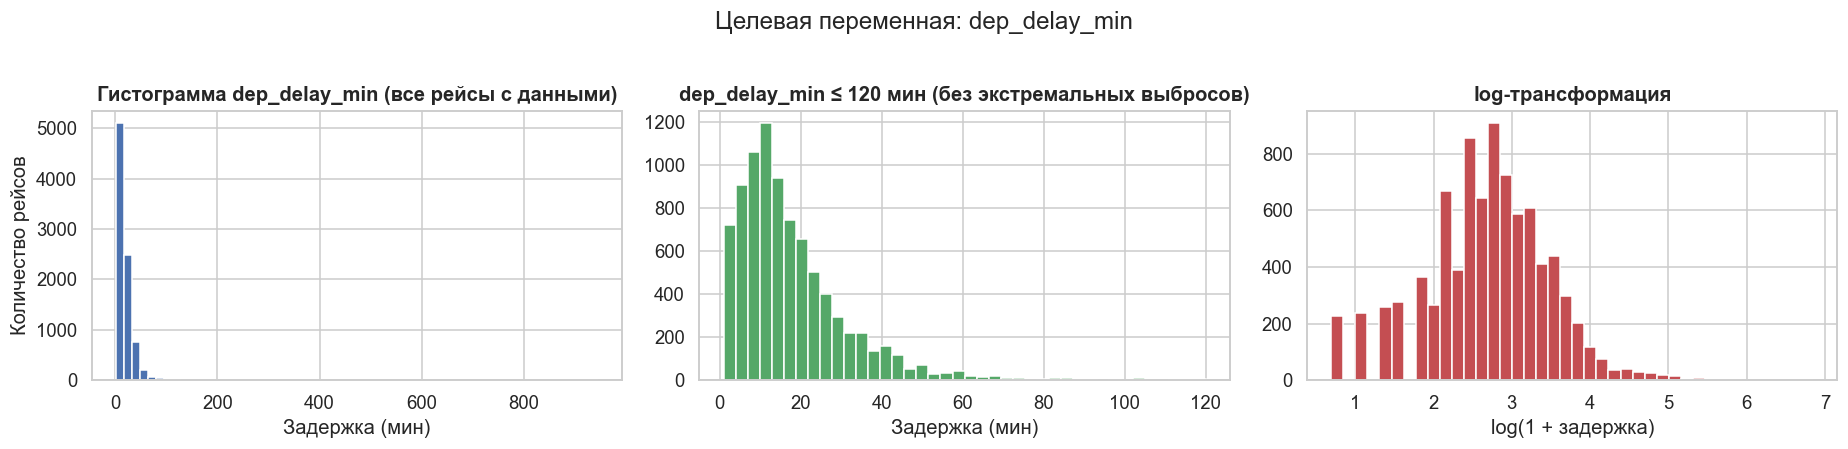

In [ ]:
# 2.1 Распределение dep_delay_min по всей выборке (только где есть значение)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Целевая переменная: dep_delay_min", y=1.02)

df_known = df.dropna(subset=["dep_delay_min"])

axes[0].hist(df_known["dep_delay_min"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Задержка (мин)")
axes[0].set_ylabel("Количество рейсов")
axes[0].set_title("Гистограмма dep_delay_min (все рейсы с данными)")

axes[1].hist(df_known[df_known["dep_delay_min"] <= 120]["dep_delay_min"],
             bins=40, color="#55A868", edgecolor="white")
axes[1].set_xlabel("Задержка (мин)")
axes[1].set_title("dep_delay_min ≤ 120 мин (без экстремальных выбросов)")

axes[2].hist(np.log1p(df_known["dep_delay_min"]), bins=40,
             color="#C44E52", edgecolor="white")
axes[2].set_xlabel("log(1 + задержка)")
axes[2].set_title("log-трансформация")

plt.tight_layout()
plt.savefig("../media/eda/eda_01_target_distribution.png", bbox_inches="tight")
plt.show()

Баланс классов is_delayed
is_delayed
False    4821
NaN      4751
True     3937
Name: count, dtype: int64
Процент задержанных (среди размеченных): 45.0%
Процент НЕзадержанных: 55.0%
Без метки (active/unknown/cancelled): 4,751


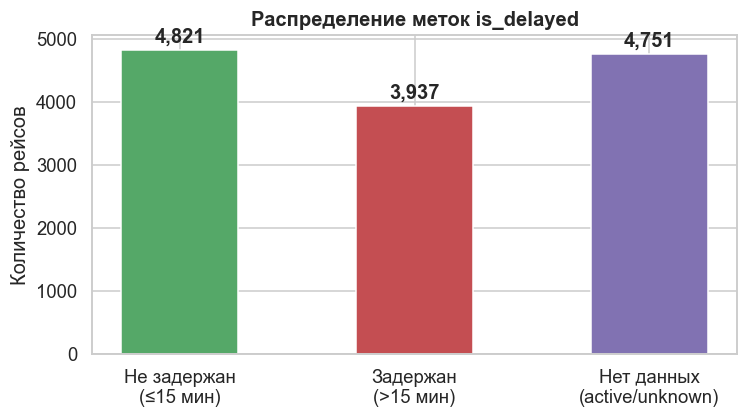

In [512]:
# 2.2 Балансировка классов
counts = df["is_delayed"].value_counts(dropna=False)

print("Баланс классов is_delayed")
print(counts)

print(f"Процент задержанных (среди размеченных): "
      f"{counts[True]/(counts[True]+counts[False])*100:.1f}%")
print(f"Процент НЕзадержанных: "
      f"{counts[False]/(counts[True]+counts[False])*100:.1f}%")
print(f"Без метки (active/unknown/cancelled): {df['is_delayed'].isna().sum():,}")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#55A868", "#C44E52", "#8172B2"]
labels = ["Не задержан\n(≤15 мин)", "Задержан\n(>15 мин)", "Нет данных\n(active/unknown)"]
vals   = [counts[False], counts[True], df["is_delayed"].isna().sum()]
bars = ax.bar(labels, vals, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Распределение меток is_delayed")
ax.set_ylabel("Количество рейсов")
plt.tight_layout()
plt.savefig("../media/eda/eda_02_class_balance.png", bbox_inches="tight")
plt.show()

Статус рейса
status
active       6081
landed       4907
unknown      2482
cancelled      26
diverted       13
Name: count, dtype: int64


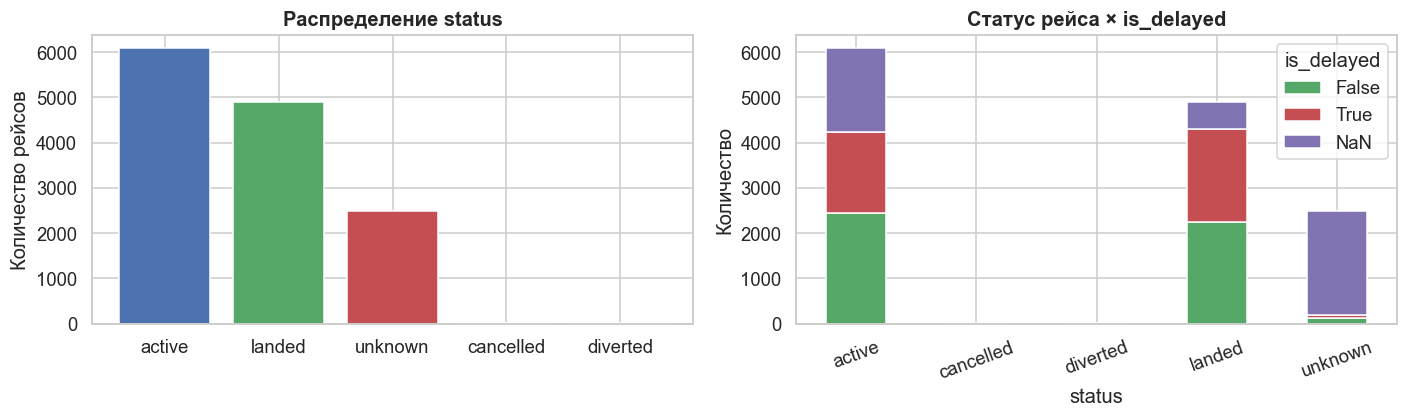

In [ ]:
# 2.3 Статус полёта vs наличие метки
print("Статус рейса")
print(df["status"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
status_counts = df["status"].value_counts()
axes[0].bar(status_counts.index, status_counts.values,
            color=["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974"],
            edgecolor="white")
axes[0].set_title("Распределение status")
axes[0].set_ylabel("Количество рейсов")

cross = pd.crosstab(df["status"], df["is_delayed"].fillna("unknown"))
cross.plot(kind="bar", ax=axes[1], stacked=True,
           color=["#55A868","#C44E52","#8172B2"], edgecolor="white")
axes[1].set_title("Статус рейса × is_delayed")
axes[1].set_xlabel("status")
axes[1].set_ylabel("Количество")
axes[1].legend(title="is_delayed", labels=["False","True","NaN"])
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("../media/eda/eda_03_status_vs_delayed.png", bbox_inches="tight")
plt.show()

- 'unknown' и 'active' почти полностью без метки → их нельзя использовать как train-примеры
- 'cancelled' (26 рейсов) это особый случай: задержка до вылета не всегда определена
- 'diverted' (13 рейсов), их очень мало, осторожно с включением

# 3. Пропуски и качество данных.

Столбцы с пропусками
                            missing_count  missing_pct
dep_terminal                         6866         50.8
notam_max_hours_arr                  5522         40.9
notam_max_hours_dep                  5394         39.9
notam_count_arr                      4974         36.8
notam_active_arr                     4974         36.8
has_restriction_arr                  4974         36.8
has_runway_closure_arr               4974         36.8
has_restriction_arr_int              4974         36.8
has_runway_closure_arr_int           4974         36.8
dep_delay_min                        4751         35.2
is_delayed                           4751         35.2
is_delayed_int                       4751         35.2
dep_elevation_ft                       28          0.2
arr_elevation_ft                       22          0.2


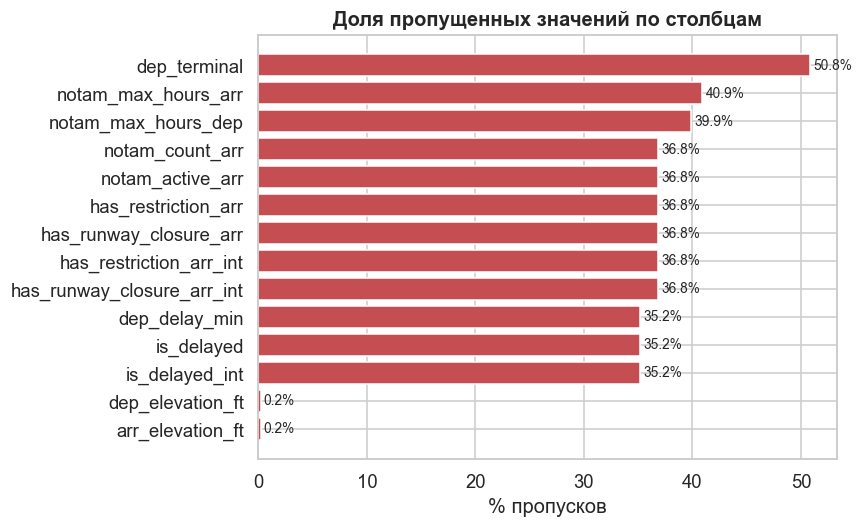

In [514]:
# 3.1 Heatmap пропусков
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
miss_df = miss_df[miss_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print("Столбцы с пропусками")
print(miss_df.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(miss_df.index, miss_df["missing_pct"],
               color="#C44E52", edgecolor="white")
ax.set_xlabel("% пропусков")
ax.set_title("Доля пропущенных значений по столбцам")
for bar, val in zip(bars, miss_df["missing_pct"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../media/eda/eda_04_missing_values.png", bbox_inches="tight")
plt.show()

In [515]:
# 3.2 Анализ структуры пропусков в NOTAM-столбцах
print("Связь пропусков в NOTAM с флагом arr_notams_available")
print(pd.crosstab(df["arr_notams_available"], df["notam_count_arr"].isna(),
                  margins=True))
# Ожидаем: когда arr_notams_available=False → notam_count_arr = NaN

Связь пропусков в NOTAM с флагом arr_notams_available
notam_count_arr       False  True    All
arr_notams_available                    
False                     0  4974   4974
True                   8535     0   8535
All                    8535  4974  13509


In [ ]:

# 3.3 Пропуски is_delayed в зависимости от status
print("Пропуски is_delayed по status")
print(df.groupby("status")["is_delayed"].apply(
    lambda x: x.isna().sum()).rename("is_delayed_NaN"))

# ВЫВОД:
# Группа 1 (MCAR-пропуски): dep_elevation_ft, arr_elevation_ft — почти нет (<0.3%)
# Группа 2 (MAR-пропуски):
#   - dep_delay_min / is_delayed: пропуски строго зависят от status
#     (active, unknown, cancelled) → NOT RANDOM, нельзя просто импутировать
#   - notam_count_arr / notam_max_hours_*: зависят от *_notams_available флага
#   - dep_terminal: структурный пропуск (аэропорты без терминалов)


Размеченная выборка (landed + часть active): 8,758 рейсов


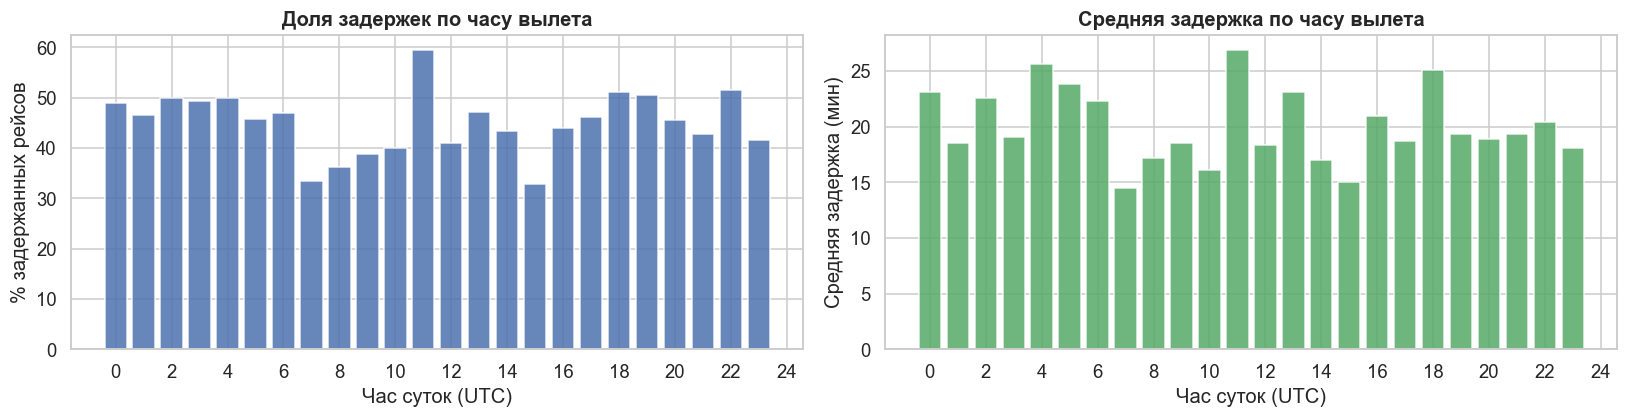

In [469]:
# =============================================================================
# ── 4. ВРЕМЕННЫЕ ПРИЗНАКИ ────────────────────────────────────────────────────
# =============================================================================

# Работаем только с размеченными рейсами
df_labeled = df.dropna(subset=["is_delayed"]).copy()
print(f"\nРазмеченная выборка (landed + часть active): {len(df_labeled):,} рейсов")

# 4.1 Задержки по часу суток
hour_stats = df_labeled.groupby("hour_of_day").agg(
    delay_rate=("is_delayed", "mean"),
    avg_delay_min=("dep_delay_min", "mean"),
    count=("is_delayed", "count")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
ax1, ax2 = axes

color_bar = "#4C72B0"
ax1.bar(hour_stats["hour_of_day"], hour_stats["delay_rate"] * 100,
        color=color_bar, edgecolor="white", alpha=0.85)
ax1.set_xlabel("Час суток (UTC)")
ax1.set_ylabel("% задержанных рейсов")
ax1.set_title("Доля задержек по часу вылета")
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))

ax2.bar(hour_stats["hour_of_day"], hour_stats["avg_delay_min"],
        color="#55A868", edgecolor="white", alpha=0.85)
ax2.set_xlabel("Час суток (UTC)")
ax2.set_ylabel("Средняя задержка (мин)")
ax2.set_title("Средняя задержка по часу вылета")
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.tight_layout()
plt.savefig("../media/eda/eda_05_delay_by_hour.png", bbox_inches="tight")
plt.show()

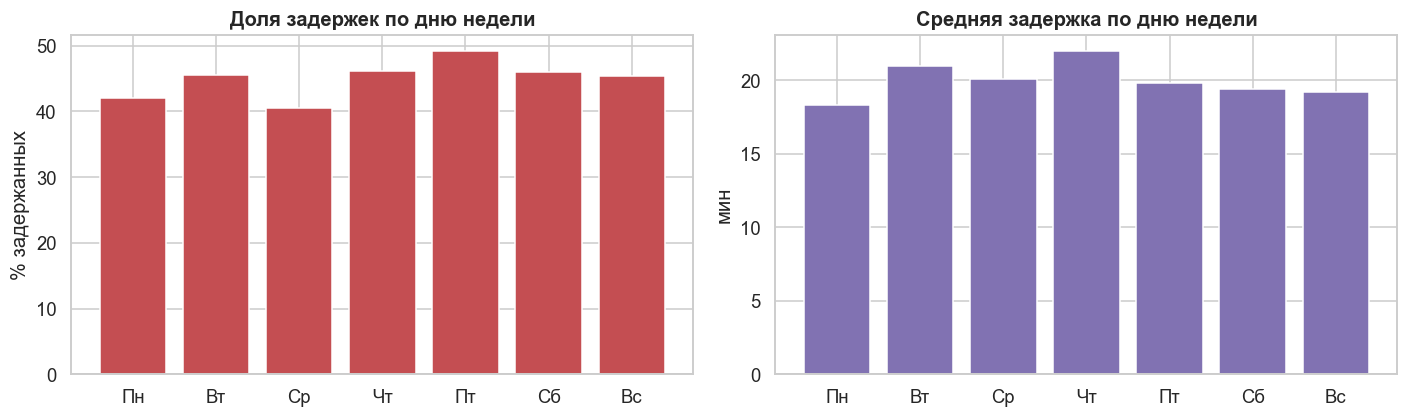

In [470]:
# 4.2 Задержки по дню недели
dow_stats = df_labeled.groupby("day_of_week").agg(
    delay_rate=("is_delayed", "mean"),
    avg_delay_min=("dep_delay_min", "mean")
).reset_index()
dow_names = {0:"Пн",1:"Вт",2:"Ср",3:"Чт",4:"Пт",5:"Сб",6:"Вс"}
dow_stats["day_name"] = dow_stats["day_of_week"].map(dow_names)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(dow_stats["day_name"], dow_stats["delay_rate"]*100,
            color="#C44E52", edgecolor="white")
axes[0].set_title("Доля задержек по дню недели")
axes[0].set_ylabel("% задержанных")
axes[1].bar(dow_stats["day_name"], dow_stats["avg_delay_min"],
            color="#8172B2", edgecolor="white")
axes[1].set_title("Средняя задержка по дню недели")
axes[1].set_ylabel("мин")
plt.tight_layout()
plt.savefig("../media/eda/eda_06_delay_by_dow.png", bbox_inches="tight")
plt.show()

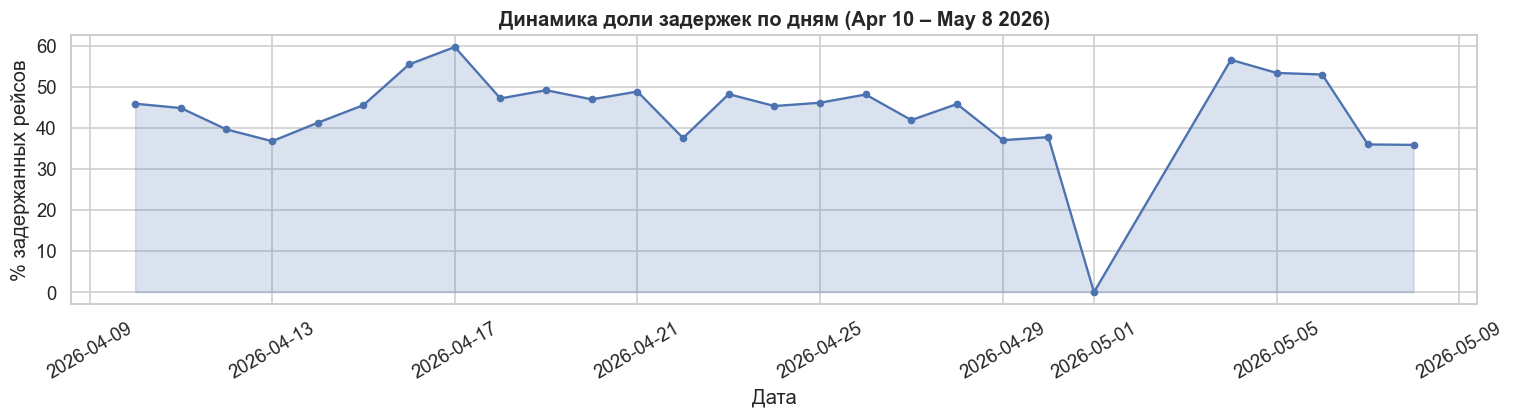

In [471]:
# 4.3 Динамика задержек во времени (по дням)
df_labeled["date"] = pd.to_datetime(df_labeled["dep_scheduled_utc"]).dt.floor("D")

daily = df_labeled.groupby("date").agg(
    delay_rate=("is_delayed", "mean"),
    count=("is_delayed", "count")
).reset_index()

x = daily["date"].to_numpy()
y = (daily["delay_rate"] * 100).astype(float).to_numpy()

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    x, y,
    marker="o",
    markersize=4,
    linewidth=1.5,
    color="#4C72B0"
)

ax.fill_between(
    x, y,
    0,
    alpha=0.2,
    color="#4C72B0"
)

ax.set_xlabel("Дата")
ax.set_ylabel("% задержанных рейсов")
ax.set_title("Динамика доли задержек по дням (Apr 10 – May 8 2026)")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../media/eda/eda_07_delay_timeseries.png", bbox_inches="tight")
plt.show()

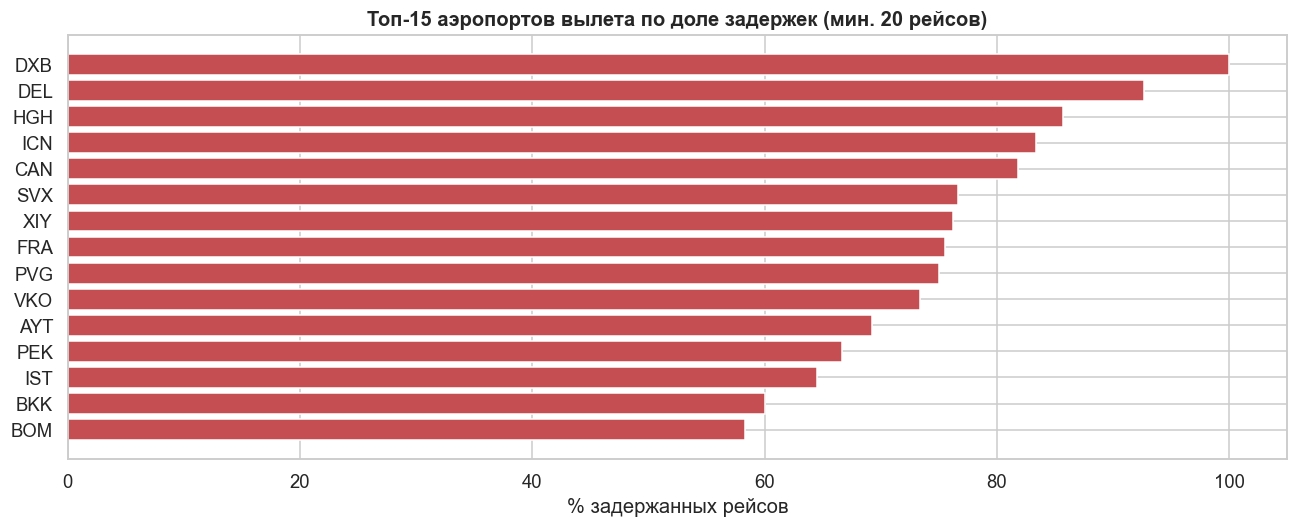

In [472]:
# =============================================================================
# ── 5. АЭРОПОРТЫ, МАРШРУТЫ, АВИАКОМПАНИИ ─────────────────────────────────────
# =============================================================================

# 5.1 Топ-15 аэропортов вылета по задержке
dep_stats = df_labeled.groupby("dep_iata").agg(
    delay_rate=("is_delayed", "mean"),
    count=("is_delayed", "count"),
    avg_delay=("dep_delay_min", "mean")
).reset_index()
dep_stats = dep_stats[dep_stats["count"] >= 20].sort_values("delay_rate", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top15 = dep_stats.head(15)
ax.barh(top15["dep_iata"], top15["delay_rate"]*100,
        color="#C44E52", edgecolor="white")
ax.set_xlabel("% задержанных рейсов")
ax.set_title("Топ-15 аэропортов вылета по доле задержек (мин. 20 рейсов)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../media/eda/eda_08_top_dep_airports.png", bbox_inches="tight")
plt.show()

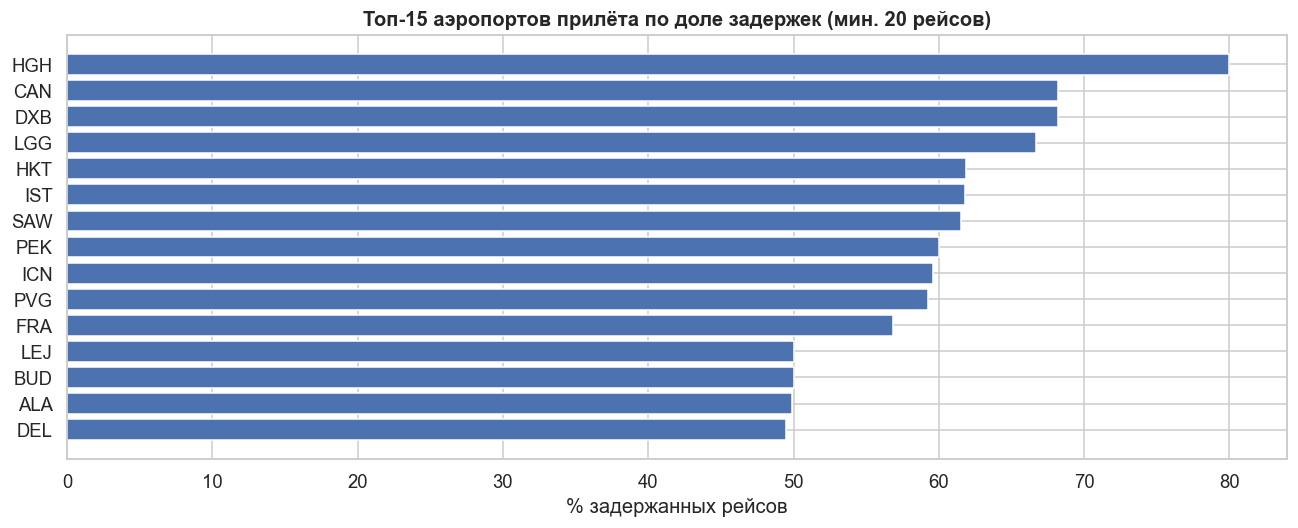

In [473]:
# 5.2 Топ-15 аэропортов прилёта
arr_stats = df_labeled.groupby("arr_iata").agg(
    delay_rate=("is_delayed", "mean"),
    count=("is_delayed", "count")
).reset_index()
arr_stats = arr_stats[arr_stats["count"] >= 20].sort_values("delay_rate", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top15a = arr_stats.head(15)
ax.barh(top15a["arr_iata"], top15a["delay_rate"]*100,
        color="#4C72B0", edgecolor="white")
ax.set_xlabel("% задержанных рейсов")
ax.set_title("Топ-15 аэропортов прилёта по доле задержек (мин. 20 рейсов)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../media/eda/eda_09_top_arr_airports.png", bbox_inches="tight")
plt.show()

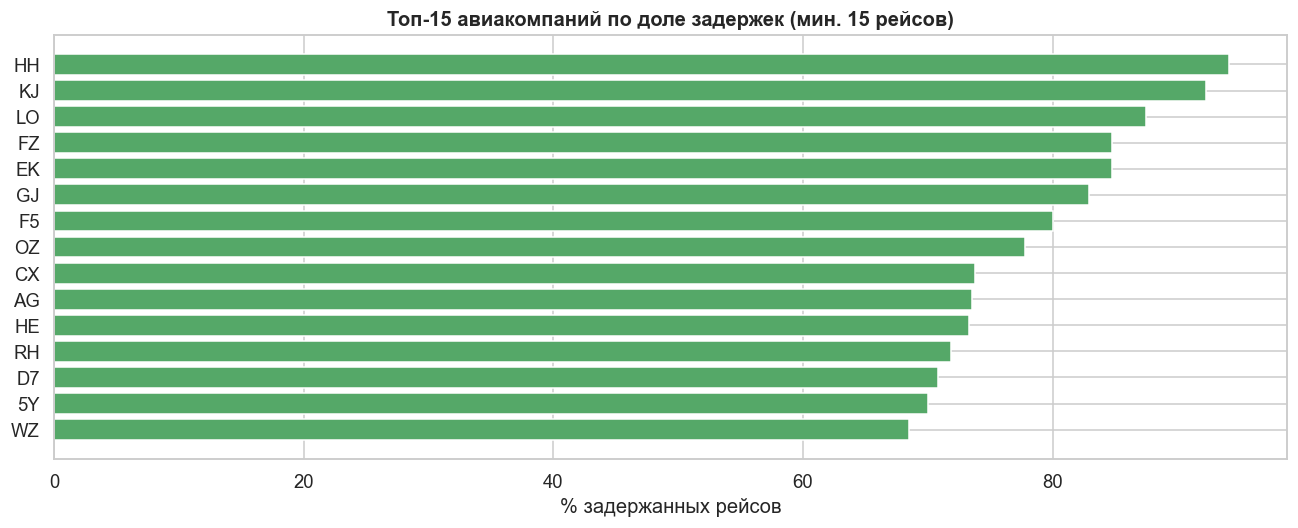

In [474]:
# 5.3 Топ-15 авиакомпаний
airline_stats = df_labeled.groupby("airline_iata").agg(
    delay_rate=("is_delayed", "mean"),
    count=("is_delayed", "count"),
    avg_delay=("dep_delay_min", "mean")
).reset_index()
airline_stats = airline_stats[airline_stats["count"] >= 15]\
    .sort_values("delay_rate", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top15al = airline_stats.head(15)
bars = ax.barh(top15al["airline_iata"], top15al["delay_rate"]*100,
               color="#55A868", edgecolor="white")
ax.set_xlabel("% задержанных рейсов")
ax.set_title("Топ-15 авиакомпаний по доле задержек (мин. 15 рейсов)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../media/eda/eda_10_airlines.png", bbox_inches="tight")
plt.show()


── Задержки: внутренние vs международные ──
is_domestic
False    54.557464
True     34.606262
Name: is_delayed, dtype: object


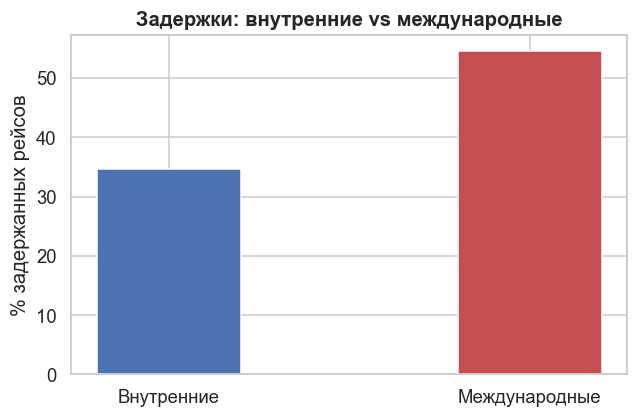

In [475]:
# 5.4 Внутренние vs международные
dom_intl = df_labeled.groupby("is_domestic")["is_delayed"].mean() * 100
print("\n── Задержки: внутренние vs международные ──")
print(dom_intl)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Внутренние", "Международные"],
       [dom_intl[True], dom_intl[False]],
       color=["#4C72B0","#C44E52"], edgecolor="white", width=0.4)
ax.set_ylabel("% задержанных рейсов")
ax.set_title("Задержки: внутренние vs международные")
plt.tight_layout()
plt.savefig("../media/eda/eda_11_domestic_intl.png", bbox_inches="tight")
plt.show()

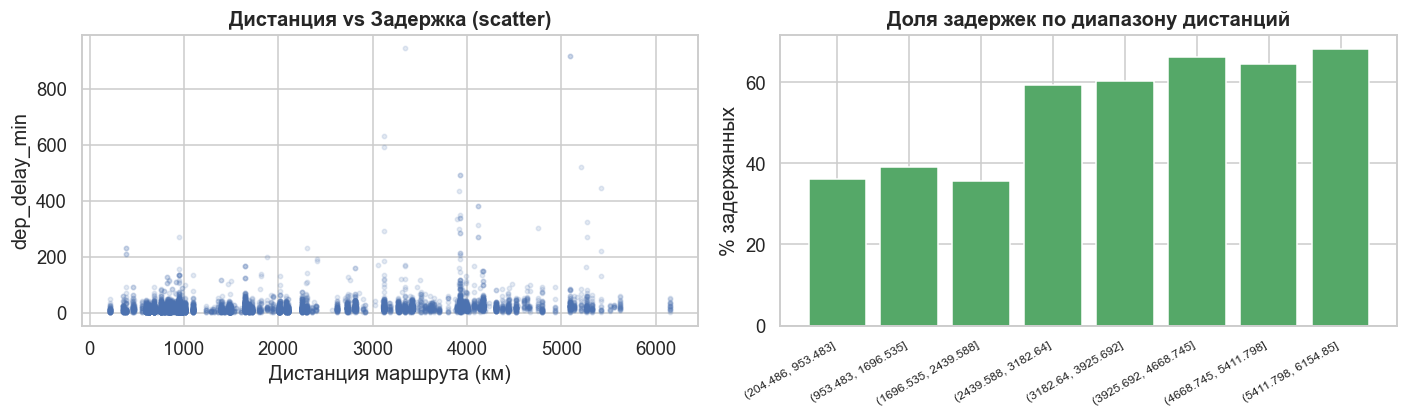

In [476]:
# 5.5 Дистанция маршрута vs задержка
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(df_labeled["route_distance_km"],
                df_labeled["dep_delay_min"],
                alpha=0.15, s=8, color="#4C72B0")
axes[0].set_xlabel("Дистанция маршрута (км)")
axes[0].set_ylabel("dep_delay_min")
axes[0].set_title("Дистанция vs Задержка (scatter)")

bins = pd.cut(df_labeled["route_distance_km"], bins=8)
dist_delay = df_labeled.groupby(bins)["is_delayed"].mean() * 100
axes[1].bar(range(len(dist_delay)), dist_delay.values,
            color="#55A868", edgecolor="white")
axes[1].set_xticks(range(len(dist_delay)))
axes[1].set_xticklabels([str(b) for b in dist_delay.index], rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("% задержанных")
axes[1].set_title("Доля задержек по диапазону дистанций")
plt.tight_layout()
plt.savefig("../media/eda/eda_12_distance_delay.png", bbox_inches="tight")
plt.show()


── NOTAM доступность ──
dep_notams_available: dep_notams_available
True     8647
False    4862
Name: count, dtype: int64
arr_notams_available: arr_notams_available
True     8535
False    4974
Name: count, dtype: int64


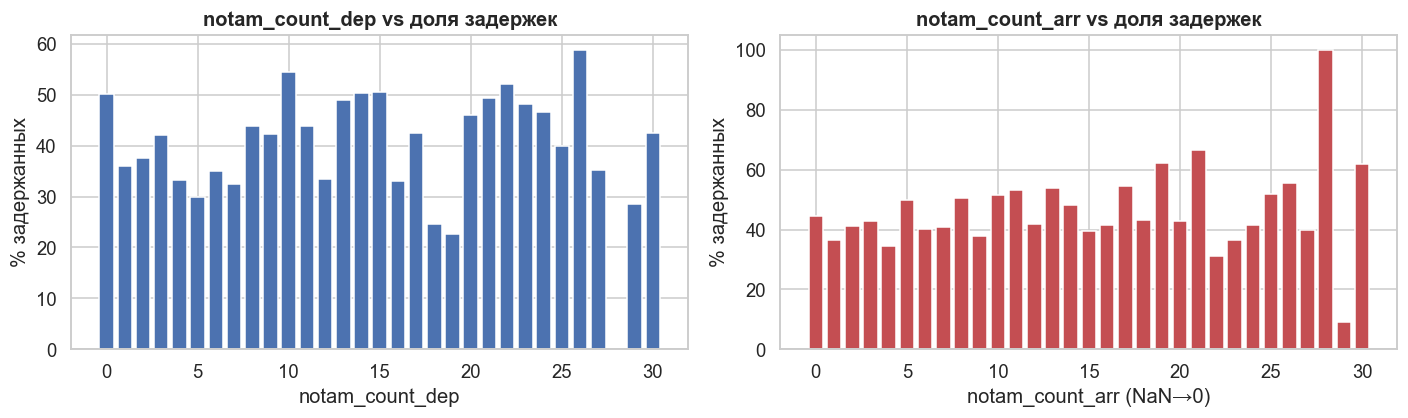

In [477]:

# =============================================================================
# ── 6. NOTAM-ПРИЗНАКИ ────────────────────────────────────────────────────────
# =============================================================================

# 6.1 Доступность NOTAM данных
print("\n── NOTAM доступность ──")
print("dep_notams_available:", df["dep_notams_available"].value_counts())
print("arr_notams_available:", df["arr_notams_available"].value_counts())

# 6.2 notam_count_dep/arr vs задержка
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

notam_dep = df_labeled.groupby("notam_count_dep")["is_delayed"].mean() * 100
top_counts = notam_dep[notam_dep.index <= 30]  # обрезаем хвост для читаемости
axes[0].bar(top_counts.index, top_counts.values,
            color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("notam_count_dep")
axes[0].set_ylabel("% задержанных")
axes[0].set_title("notam_count_dep vs доля задержек")

# notam_count_arr: есть NaN (нет данных) — заполним 0 для анализа
notam_arr_fill = df_labeled["notam_count_arr"].fillna(0)
arr_notam_stats = df_labeled.copy()
arr_notam_stats["notam_count_arr_fill"] = notam_arr_fill
arr_notam_grouped = arr_notam_stats.groupby("notam_count_arr_fill")["is_delayed"].mean() * 100
top_arr = arr_notam_grouped[arr_notam_grouped.index <= 30]
axes[1].bar(top_arr.index, top_arr.values,
            color="#C44E52", edgecolor="white")
axes[1].set_xlabel("notam_count_arr (NaN→0)")
axes[1].set_ylabel("% задержанных")
axes[1].set_title("notam_count_arr vs доля задержек")
plt.tight_layout()
plt.savefig("../media/eda/eda_13_notam_counts.png", bbox_inches="tight")
plt.show()

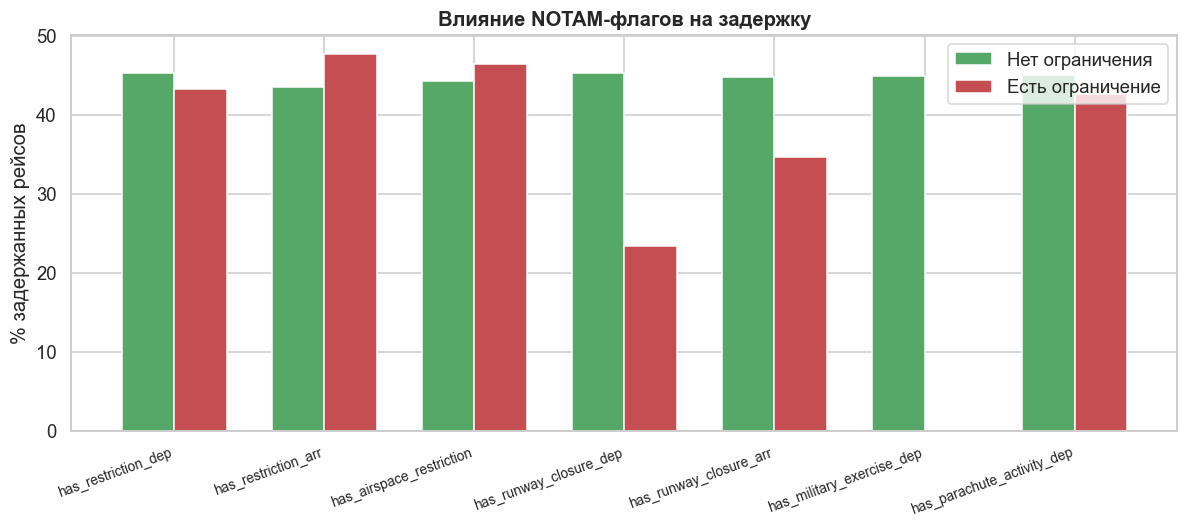

In [478]:
# 6.3 Булевые NOTAM-флаги vs задержка
notam_bool_cols = [
    "has_restriction_dep", "has_restriction_arr",
    "has_airspace_restriction", "has_runway_closure_dep",
    "has_runway_closure_arr", "has_military_exercise_dep",
    "has_parachute_activity_dep"
]

notam_effect = {}
for col in notam_bool_cols:
    group = df_labeled.dropna(subset=[col])
    rates = group.groupby(col)["is_delayed"].mean() * 100
    notam_effect[col] = {
        "no_restriction": rates.get(False, np.nan),
        "with_restriction": rates.get(True, np.nan)
    }

notam_eff_df = pd.DataFrame(notam_effect).T

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(notam_eff_df))
w = 0.35
ax.bar(x - w/2, notam_eff_df["no_restriction"], w, label="Нет ограничения",
       color="#55A868", edgecolor="white")
ax.bar(x + w/2, notam_eff_df["with_restriction"], w, label="Есть ограничение",
       color="#C44E52", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(notam_eff_df.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("% задержанных рейсов")
ax.set_title("Влияние NOTAM-флагов на задержку")
ax.legend()
plt.tight_layout()
plt.savefig("../media/eda/eda_14_notam_flags.png", bbox_inches="tight")
plt.show()

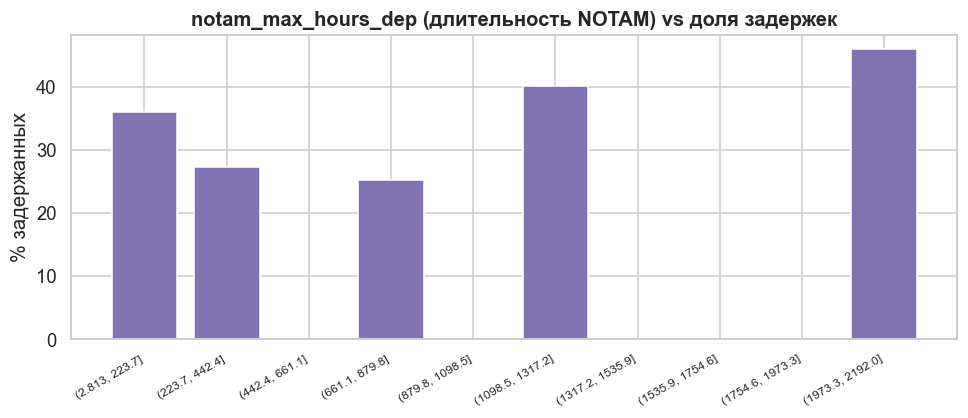

In [479]:
# 6.4 notam_max_hours — duration vs delay
fig, ax = plt.subplots(figsize=(9, 4))
df_valid_hours = df_labeled.dropna(subset=["notam_max_hours_dep"])
bins_h = pd.cut(df_valid_hours["notam_max_hours_dep"], bins=10)
hour_bin_delay = df_valid_hours.groupby(bins_h)["is_delayed"].mean() * 100
ax.bar(range(len(hour_bin_delay)), hour_bin_delay.values,
       color="#8172B2", edgecolor="white")
ax.set_xticks(range(len(hour_bin_delay)))
ax.set_xticklabels([str(b) for b in hour_bin_delay.index],
                   rotation=30, ha="right", fontsize=8)
ax.set_ylabel("% задержанных")
ax.set_title("notam_max_hours_dep (длительность NOTAM) vs доля задержек")
plt.tight_layout()
plt.savefig("../media/eda/eda_15_notam_max_hours.png", bbox_inches="tight")
plt.show()

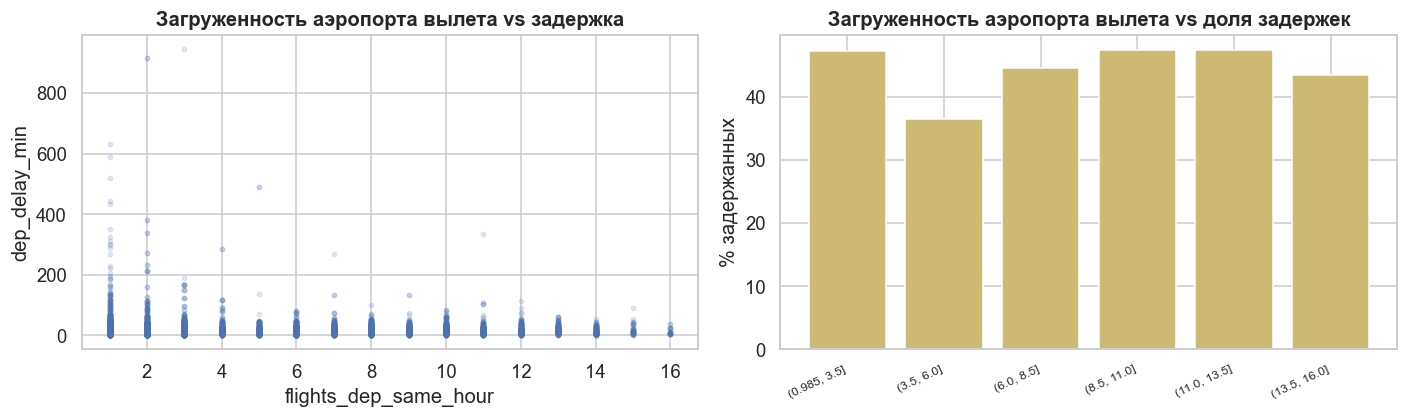

In [480]:

# =============================================================================
# ── 7. ПРИЗНАКИ ЗАГРУЖЕННОСТИ (КОНГЕСТИИ) ────────────────────────────────────
# =============================================================================

# 7.1 Scatter: flights_dep_same_hour vs delay
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df_labeled["flights_dep_same_hour"],
                df_labeled["dep_delay_min"],
                alpha=0.15, s=8, color="#4C72B0")
axes[0].set_xlabel("flights_dep_same_hour")
axes[0].set_ylabel("dep_delay_min")
axes[0].set_title("Загруженность аэропорта вылета vs задержка")

# 7.2 Box: bins по загруженности
bins_c = pd.cut(df_labeled["flights_dep_same_hour"], bins=6)
cong_df = df_labeled.copy()
cong_df["cong_bin"] = bins_c
cong_grouped = cong_df.groupby("cong_bin")["is_delayed"].mean() * 100
axes[1].bar(range(len(cong_grouped)), cong_grouped.values,
            color="#CCB974", edgecolor="white")
axes[1].set_xticks(range(len(cong_grouped)))
axes[1].set_xticklabels([str(b) for b in cong_grouped.index],
                        rotation=25, ha="right", fontsize=8)
axes[1].set_ylabel("% задержанных")
axes[1].set_title("Загруженность аэропорта вылета vs доля задержек")
plt.tight_layout()
plt.savefig("../media/eda/eda_16_congestion.png", bbox_inches="tight")
plt.show()


── Корреляция конгестии с задержкой ──
flights_dep_same_hour: -0.0743
flights_arr_same_hour: -0.0672


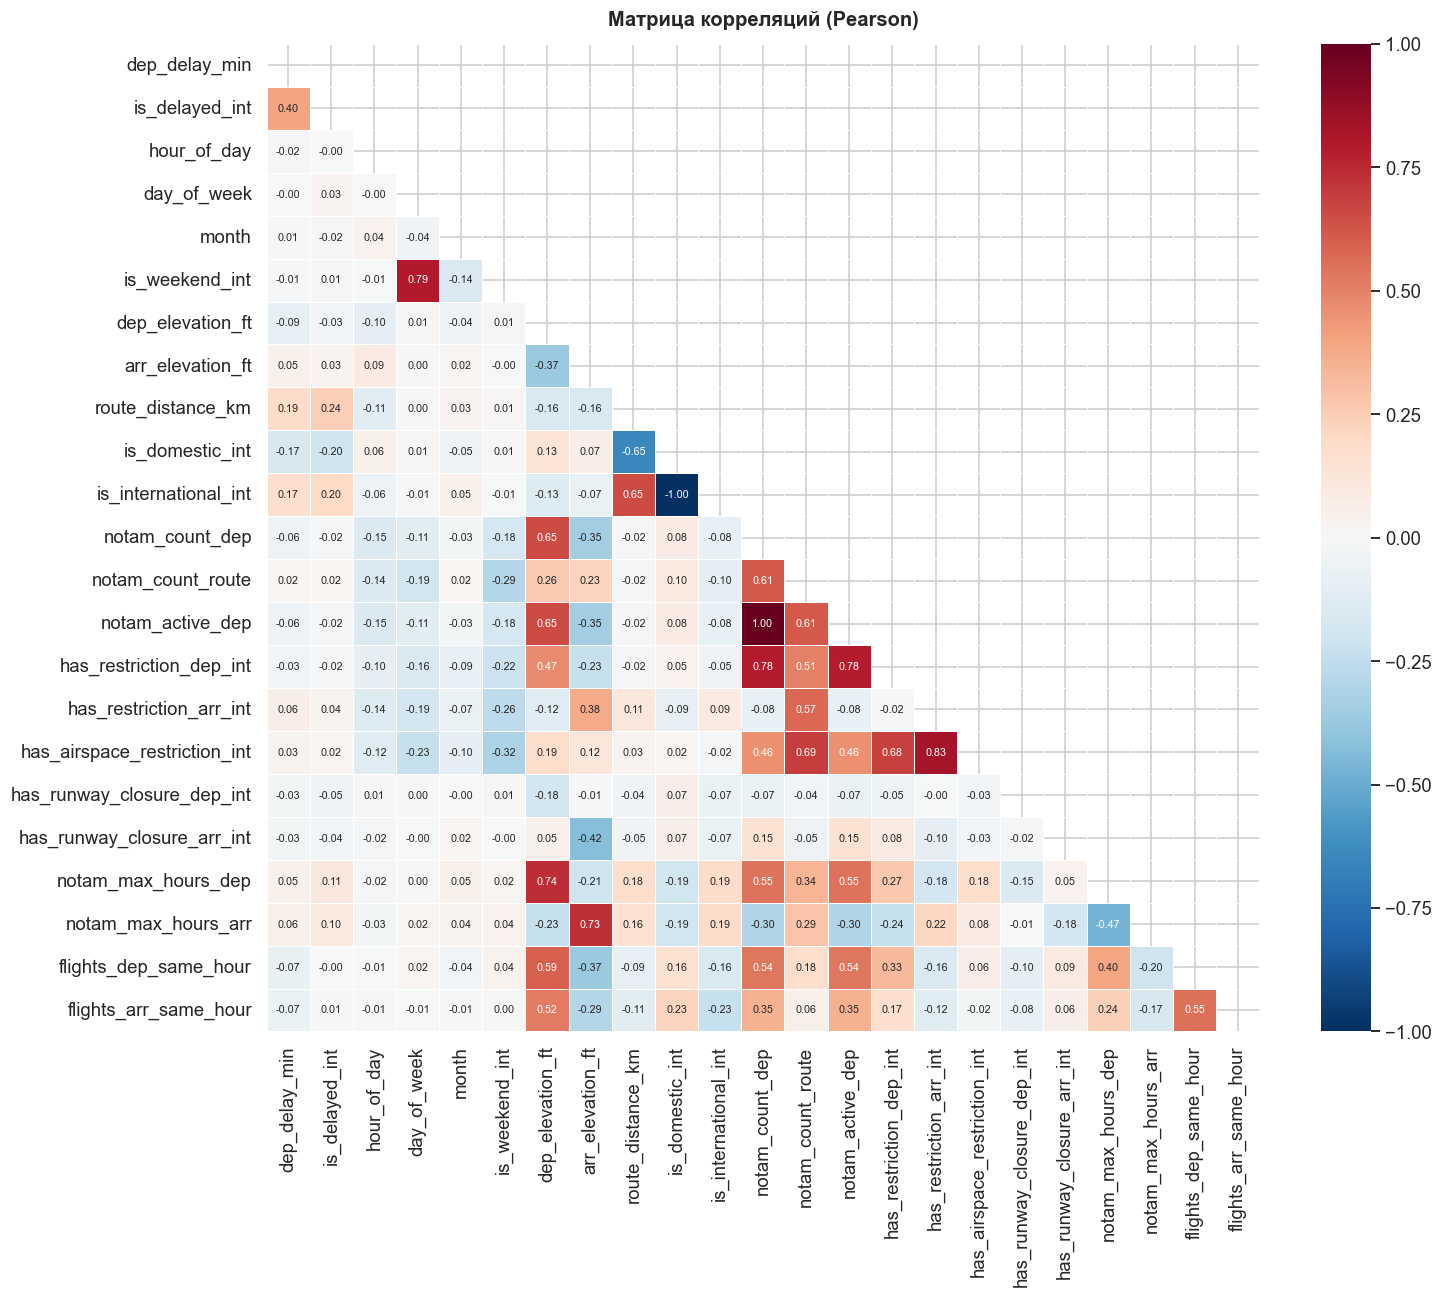

In [481]:

print("\n── Корреляция конгестии с задержкой ──")
print("flights_dep_same_hour:", df_labeled[["flights_dep_same_hour","dep_delay_min"]]
      .corr().iloc[0,1].round(4))
print("flights_arr_same_hour:", df_labeled[["flights_arr_same_hour","dep_delay_min"]]
      .corr().iloc[0,1].round(4))

# =============================================================================
# ── 8. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ──────────────────────────────────────────────────
# =============================================================================

# Выбираем числовые + закодированные булевы признаки для матрицы корреляций
NUM_FEATURES = [
    "dep_delay_min", "is_delayed_int",
    "hour_of_day", "day_of_week", "month", "is_weekend_int",
    "dep_elevation_ft", "arr_elevation_ft", "route_distance_km",
    "is_domestic_int", "is_international_int",
    "notam_count_dep", "notam_count_route",
    "notam_active_dep",
    "has_restriction_dep_int", "has_restriction_arr_int",
    "has_airspace_restriction_int",
    "has_runway_closure_dep_int", "has_runway_closure_arr_int",
    "notam_max_hours_dep", "notam_max_hours_arr",
    "flights_dep_same_hour", "flights_arr_same_hour",
]

df_num = df_labeled[NUM_FEATURES].copy()
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 7}, vmin=-1, vmax=1)
ax.set_title("Матрица корреляций (Pearson)", pad=12)
plt.tight_layout()
plt.savefig("../media/eda/eda_17_correlation_matrix.png", bbox_inches="tight")
plt.show()

In [482]:
# Топ-10 корреляций с is_delayed_int
print("\n── Топ-10 признаков по корреляции с is_delayed ──")
print(corr["is_delayed_int"].drop("is_delayed_int")
      .abs().sort_values(ascending=False).head(10).to_string())

# Point-biserial корреляции (более точны для бинарного таргета)
from scipy.stats import pointbiserialr
print("\n── Point-biserial корреляции с is_delayed ──")
target_bin = df_labeled["is_delayed"].astype(int)
for feat in [c for c in NUM_FEATURES if c not in ("dep_delay_min","is_delayed_int")]:
    col_data = df_labeled[feat]
    valid = col_data.notna() & target_bin.notna()
    if valid.sum() > 50:
        r, p = pointbiserialr(target_bin[valid], col_data[valid])
        print(f"  {feat:40s}  r={r:+.4f}  p={p:.4f}")


── Топ-10 признаков по корреляции с is_delayed ──
dep_delay_min                 0.402689
route_distance_km             0.243622
is_domestic_int               0.200397
is_international_int          0.200397
notam_max_hours_dep           0.108680
notam_max_hours_arr           0.098574
has_runway_closure_dep_int    0.048266
has_restriction_arr_int       0.036415
has_runway_closure_arr_int    0.035392
dep_elevation_ft              0.034826

── Point-biserial корреляции с is_delayed ──
  hour_of_day                               r=-0.0045  p=0.6713
  day_of_week                               r=+0.0278  p=0.0092
  month                                     r=-0.0193  p=0.0709
  is_weekend_int                            r=+0.0085  p=0.4257
  dep_elevation_ft                          r=-0.0348  p=0.0011
  arr_elevation_ft                          r=+0.0262  p=0.0142
  route_distance_km                         r=+0.2436  p=0.0000
  is_domestic_int                           r=-0.2004  p=0.0000
 


── Анализ выбросов dep_delay_min (среди задержанных) ──
  Q1=19  Q3=35  IQR=16
  Верхняя граница (3×IQR): 83 мин
  Выбросов выше границы: 152
  Рейсов с задержкой > 300 мин: 19
  Рейсов с задержкой > 480 мин (8 ч): 8


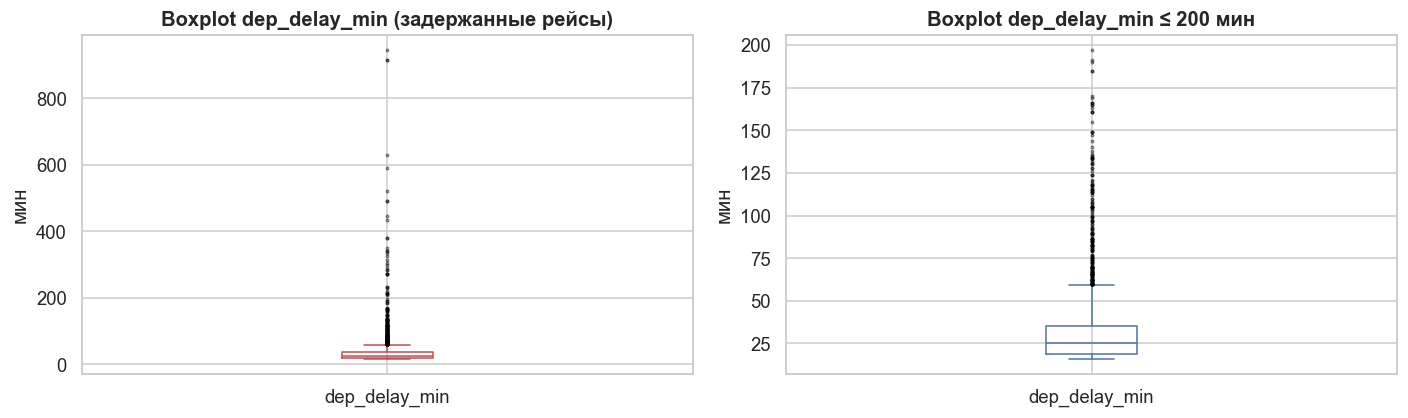

In [483]:
# =============================================================================
# ── 9. АНАЛИЗ ВЫБРОСОВ ────────────────────────────────────────────────────────
# =============================================================================

print("\n── Анализ выбросов dep_delay_min (среди задержанных) ──")
delayed_only = df_labeled[df_labeled["is_delayed"] == True]["dep_delay_min"]

q1, q3 = delayed_only.quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 3 * iqr  # мягкий вариант: 3*IQR

print(f"  Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}")
print(f"  Верхняя граница (3×IQR): {upper_fence:.0f} мин")
print(f"  Выбросов выше границы: {(delayed_only > upper_fence).sum()}")
print(f"  Рейсов с задержкой > 300 мин: {(delayed_only > 300).sum()}")
print(f"  Рейсов с задержкой > 480 мин (8 ч): {(delayed_only > 480).sum()}")

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
delayed_only.plot(kind="box", ax=axes[0], color="#C44E52",
                  flierprops=dict(marker=".", markersize=3, alpha=0.5))
axes[0].set_title("Boxplot dep_delay_min (задержанные рейсы)")
axes[0].set_ylabel("мин")

delayed_only[delayed_only <= 200].plot(kind="box", ax=axes[1], color="#4C72B0",
                                        flierprops=dict(marker=".", markersize=3, alpha=0.5))
axes[1].set_title("Boxplot dep_delay_min ≤ 200 мин")
axes[1].set_ylabel("мин")
plt.tight_layout()
plt.savefig("../media/eda/eda_18_outliers.png", bbox_inches="tight")
plt.show()

In [484]:
# Характеристики extreme-outlier рейсов
print("\n── Extreme выбросы (dep_delay_min > 300 мин) ──")
extreme = df_labeled[df_labeled["dep_delay_min"] > 300][
    ["flight_iata","dep_iata","arr_iata","airline_iata","status",
     "dep_delay_min","is_delayed"]
].sort_values("dep_delay_min", ascending=False)
print(extreme.to_string())

# =============================================================================
# ── 10. ОБОСНОВАННАЯ СТРАТЕГИЯ ОЧИСТКИ ДАННЫХ ────────────────────────────────
# =============================================================================

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║         СТРАТЕГИЯ ОЧИСТКИ И ПОДГОТОВКИ ДАННЫХ (с обоснованием)             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║ 1. ФИЛЬТРАЦИЯ СТРОК ПО STATUS                                               ║
║    ├─ УДАЛИТЬ: status='unknown', 'active' → dep_delay_min/is_delayed = NaN  ║
║    │   Обоснование: рейс ещё не завершён или данные не получены.             ║
║    │   Обучать модель на NaN-таргете нельзя; включение в тест                ║
║    │   также опасно (истинная метка неизвестна).                             ║
║    ├─ УДАЛИТЬ: status='cancelled' (26 рейсов)                               ║
║    │   Обоснование: отмена ≠ задержка; иная причинная структура.            ║
║    │   Слишком мало образцов (~0.2%) для отдельного класса.                  ║
║    └─ ОСТАВИТЬ: status='landed', 'diverted'                                 ║
║        Обоснование: 'diverted' имеет реальный вылет и задержку.             ║
║                                                                              ║
║ 2. ОБРАБОТКА ПРОПУСКОВ                                                       ║
║    ├─ dep_elevation_ft / arr_elevation_ft (<0.3%): median imputation        ║
║    │   по аэропорту (dep_iata/arr_iata). Аэропорты стабильны.               ║
║    ├─ notam_count_arr / notam_active_arr / has_restriction_arr:              ║
║    │   заполнить 0 / False — если arr_notams_available=False, значит        ║
║    │   NOTAM-данных нет → безопаснее трактовать как "нет ограничений".       ║
║    ├─ notam_max_hours_dep / arr: много NaN (~40%).                           ║
║    │   Заполнить 0 когда нет активных NOTAM; иначе — median по аэропорту.   ║
║    └─ dep_terminal: высокий % NaN (51%) → оставить как категорию,           ║
║        добавить флаг "terminal_known" (0/1).                                 ║
║                                                                              ║
║ 3. ВЫБРОСЫ dep_delay_min                                                     ║
║    ├─ Задержки > 480 мин (8 ч) — 8 рейсов (~0.06% выборки).                ║
║    │   НЕ УДАЛЯТЬ для классификации (is_delayed=True — корректно).          ║
║    └─ Для задачи регрессии: кэпинг на 480 мин (cap + log-трансформация)    ║
║       или robust-модели (LightGBM с MAE-лоссом). MAE менее чувствителен.    ║
║                                                                              ║
║ 4. ДУБЛИРУЮЩИЕСЯ РЕЙСЫ (CODESHARE)                                          ║
║    ├─ Рейсы TK352/MS9300/KC1352 летят с одного борта в одно время.         ║
║    │   Для классификации — ОСТАВИТЬ всех (разные airline_iata — признак).   ║
║    └─ При расчёте конгестии использовать уникальные (dep, arr, time).        ║
║                                                                              ║
║ 5. УТЕЧКА ДАННЫХ (DATA LEAKAGE)                                              ║
║    └─ dep_delay_min НЕЛЬЗЯ использовать как признак для классификации       ║
║       is_delayed — это и есть источник таргета. Исключить из feature-матрицы║
║                                                                              ║
║ 6. TEMPORAL SPLIT                                                            ║
║    ├─ Train:  Apr 10 – Apr 28 (~80%)                                         ║
║    └─ Test:   Apr 29 – May 8  (~20%)                                         ║
║       Обоснование: нельзя перемешивать будущее и прошлое.                    ║
║       Стандартный random split создаёт утечку через временные паттерны.      ║
║                                                                              ║
║ 7. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ                                      ║
║    ├─ airline_iata, dep_iata, arr_iata → Target Encoding (+ CV fold mean)   ║
║    ├─ dep_iso_country, arr_iso_country → частотное / OHE (небольшой словарь)║
║    ├─ season → OHE (4 значения)                                              ║
║    └─ dep_terminal → OHE + флаг "unknown"                                   ║
║                                                                              ║
║ 8. МАСШТАБИРОВАНИЕ                                                           ║
║    └─ Числовые признаки: StandardScaler для Logistic Regression baseline.   ║
║       LightGBM/XGBoost масштабирования не требуют.                           ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


── Extreme выбросы (dep_delay_min > 300 мин) ──
      flight_iata dep_iata arr_iata airline_iata   status  dep_delay_min is_delayed
3443       GO6239      CIT      IST           GO   active          945.0       True
3711       LH9610      FRA      ALA           LH  unknown          915.0       True
3710        KC222      FRA      ALA           KC  unknown          915.0       True
10594      DV3415      VKO      ALA           DV  unknown          630.0       True
13035       DV810      VKO      ALA           DV  unknown          590.0       True
3624        HE774      EMA      CIT           HE  unknown          520.0       True
1060       RH9488      IST      ALA           RH  unknown          490.0       True
1059       TK6782      IST      ALA           TK  unknown          490.0       True
6401        KC174      PQC      NQZ           KC   landed          445.0       True
1749       TK6381      CGO      CIT           TK   landed          434.0       True
10042      TK6781      HKG 

In [485]:
# ======================================================================
# ── 10. DUPLICATE AND CONSISTENCY CHECKS
# ======================================================================

print("\n" + "="*80)
print("10. DUPLICATE AND CONSISTENCY CHECKS")
print("="*80)

# 10.1 Полные дубликаты строк
full_duplicates = df.duplicated().sum()
print(f"\nПолные дубликаты строк: {full_duplicates:,}")


10. DUPLICATE AND CONSISTENCY CHECKS

Полные дубликаты строк: 0


In [486]:
# 10.2 Потенциальные дубликаты одного и того же рейса
flight_key_cols = ["flight_iata", "dep_scheduled_utc", "dep_iata", "arr_iata"]

existing_flight_key_cols = [c for c in flight_key_cols if c in df.columns]

if len(existing_flight_key_cols) == len(flight_key_cols):
    flight_duplicates = df.duplicated(subset=flight_key_cols, keep=False).sum()
    print(f"Потенциальные дубликаты рейсов по {flight_key_cols}: {flight_duplicates:,}")

    dup_flights = (
        df[df.duplicated(subset=flight_key_cols, keep=False)]
        .sort_values(flight_key_cols)
        [flight_key_cols + ["status", "dep_delay_min", "is_delayed", "updated_at"]]
    )

    print("\nПримеры потенциальных дубликатов рейсов:")
    display(dup_flights.head(20))
else:
    print("Не все ключевые колонки для проверки дубликатов найдены.")

Потенциальные дубликаты рейсов по ['flight_iata', 'dep_scheduled_utc', 'dep_iata', 'arr_iata']: 0

Примеры потенциальных дубликатов рейсов:


,flight_iata,dep_scheduled_utc,dep_iata,arr_iata,status,dep_delay_min,is_delayed,updated_at


In [487]:
# 10.3 Проверка противоречий между dep_delay_min и is_delayed
df_check = df.dropna(subset=["dep_delay_min", "is_delayed"]).copy()
df_check["is_delayed_from_delay"] = df_check["dep_delay_min"] > 15

target_mismatch = (df_check["is_delayed"] != df_check["is_delayed_from_delay"]).sum()

print(f"\nПротиворечия между dep_delay_min > 15 и is_delayed: {target_mismatch:,}")

if target_mismatch > 0:
    print("\nПримеры противоречий:")
    display(
        df_check[df_check["is_delayed"] != df_check["is_delayed_from_delay"]]
        [["flight_iata", "dep_scheduled_utc", "dep_delay_min", "is_delayed", "is_delayed_from_delay", "status"]]
        .head(20)
    )


Противоречия между dep_delay_min > 15 и is_delayed: 0


In [488]:
# 10.4 Проверка отрицательных / нулевых / экстремальных задержек
print("\nПроверка dep_delay_min:")
print(f"Минимум: {df['dep_delay_min'].min()}")
print(f"Максимум: {df['dep_delay_min'].max()}")
print(f"Количество dep_delay_min < 0: {(df['dep_delay_min'] < 0).sum():,}")
print(f"Количество dep_delay_min == 0: {(df['dep_delay_min'] == 0).sum():,}")
print(f"Количество dep_delay_min > 180: {(df['dep_delay_min'] > 180).sum():,}")
print(f"Количество dep_delay_min > 300: {(df['dep_delay_min'] > 300).sum():,}")


Проверка dep_delay_min:
Минимум: 1.0
Максимум: 945.0
Количество dep_delay_min < 0: 0
Количество dep_delay_min == 0: 0
Количество dep_delay_min > 180: 41
Количество dep_delay_min > 300: 19


In [489]:
# 10.5 Проверка координат и дистанций
coord_checks = {
    "dep_latitude_out_of_range": (~df["dep_latitude"].between(-90, 90)).sum(),
    "arr_latitude_out_of_range": (~df["arr_latitude"].between(-90, 90)).sum(),
    "dep_longitude_out_of_range": (~df["dep_longitude"].between(-180, 180)).sum(),
    "arr_longitude_out_of_range": (~df["arr_longitude"].between(-180, 180)).sum(),
    "route_distance_missing": df["route_distance_km"].isna().sum(),
    "route_distance_non_positive": (df["route_distance_km"] <= 0).sum(),
}

print("\nПроверка координат и route_distance_km:")
for k, v in coord_checks.items():
    print(f"{k}: {v:,}")


Проверка координат и route_distance_km:
dep_latitude_out_of_range: 0
arr_latitude_out_of_range: 0
dep_longitude_out_of_range: 0
arr_longitude_out_of_range: 0
route_distance_missing: 0
route_distance_non_positive: 0


In [490]:
# 10.6 Проверка логики domestic / international
if {"is_domestic", "is_international"}.issubset(df.columns):
    both_true = ((df["is_domestic"] == True) & (df["is_international"] == True)).sum()
    both_false = ((df["is_domestic"] == False) & (df["is_international"] == False)).sum()
    print("\nПроверка is_domestic / is_international:")
    print(f"Оба True: {both_true:,}")
    print(f"Оба False: {both_false:,}")


Проверка is_domestic / is_international:
Оба True: 0
Оба False: 0


In [491]:

# 10.7 Проверка соответствия domestic country logic
if {"dep_iso_country", "arr_iso_country", "is_domestic"}.issubset(df.columns):
    country_domestic = df["dep_iso_country"] == df["arr_iso_country"]
    domestic_mismatch = (country_domestic != df["is_domestic"]).sum()
    print(f"\nПротиворечия is_domestic vs dep_country == arr_country: {domestic_mismatch:,}")

    if domestic_mismatch > 0:
        display(
            df[country_domestic != df["is_domestic"]]
            [["dep_iata", "arr_iata", "dep_iso_country", "arr_iso_country", "is_domestic", "is_international"]]
            .head(20)
        )


Противоречия is_domestic vs dep_country == arr_country: 0


In [492]:
# ======================================================================
# ── 11. LEAKAGE AUDIT
# ======================================================================

print("\n" + "="*80)
print("11. LEAKAGE AUDIT")
print("="*80)

leakage_audit = pd.DataFrame([
    {
        "column": "dep_delay_min",
        "decision": "DROP from classification features",
        "reason": "Source of target is_delayed. Direct leakage for binary classification."
    },
    {
        "column": "is_delayed",
        "decision": "TARGET only",
        "reason": "Binary target variable, not a feature."
    },
    {
        "column": "status",
        "decision": "DROP from features",
        "reason": "Post-event / operational outcome. In real pre-departure prediction this is not known."
    },
    {
        "column": "updated_at",
        "decision": "DROP from features",
        "reason": "Technical data collection timestamp, not a business predictor."
    },
    {
        "column": "flight_iata",
        "decision": "DROP in baseline dataset",
        "reason": "High-cardinality flight identifier. Strong memorization risk."
    },
    {
        "column": "flight_number",
        "decision": "DROP in baseline dataset",
        "reason": "Identifier-like feature. Can memorize route/schedule patterns instead of generalizing."
    },
    {
        "column": "airline_icao",
        "decision": "DROP if airline_iata is used",
        "reason": "Duplicate airline representation. Keep one airline code to avoid redundancy."
    },
    {
        "column": "dep_scheduled_utc",
        "decision": "USE only for derived temporal features",
        "reason": "Raw timestamp can overfit to collection period. Use hour/day/week features instead."
    },
    {
        "column": "dep_terminal",
        "decision": "DROP in baseline dataset",
        "reason": "About 50% missing. Can be tested later, but not reliable for first clean dataset."
    },
])

display(leakage_audit)

# Сохраним таблицу для отчета
leakage_audit.to_csv(DATA_DIR / "leakage_audit_table.csv", index=False)

print("\nLeakage audit table saved to:", DATA_DIR / "leakage_audit_table.csv")


11. LEAKAGE AUDIT


,column,decision,reason
0,dep_delay_min,DROP from classification features,Source of target is_delayed. Direct leakage fo...
1,is_delayed,TARGET only,"Binary target variable, not a feature."
2,status,DROP from features,Post-event / operational outcome. In real pre-...
3,updated_at,DROP from features,"Technical data collection timestamp, not a bus..."
4,flight_iata,DROP in baseline dataset,High-cardinality flight identifier. Strong mem...
5,flight_number,DROP in baseline dataset,Identifier-like feature. Can memorize route/sc...
6,airline_icao,DROP if airline_iata is used,Duplicate airline representation. Keep one air...
7,dep_scheduled_utc,USE only for derived temporal features,Raw timestamp can overfit to collection period...
8,dep_terminal,DROP in baseline dataset,"About 50% missing. Can be tested later, but no..."



Leakage audit table saved to: ..\data\leakage_audit_table.csv



12. CATEGORICAL CARDINALITY ANALYSIS


,column,n_unique,missing_pct,top_value,top_value_pct
0,flight_iata,1279,0.00,EY5276,0.33
1,dep_iata,97,0.00,ALA,31.27
2,arr_iata,95,0.00,ALA,30.86
12,dep_municipality,94,0.00,Almaty,31.27
17,arr_municipality,92,0.00,Almaty,30.86
11,dep_iso_region,87,0.00,KZ-ALA,31.27
4,airline_icao,86,0.00,KZR,22.85
16,arr_iso_region,85,0.00,KZ-ALA,30.86
3,airline_iata,81,0.00,KC,22.85
10,dep_iso_country,39,0.00,KZ,75.61


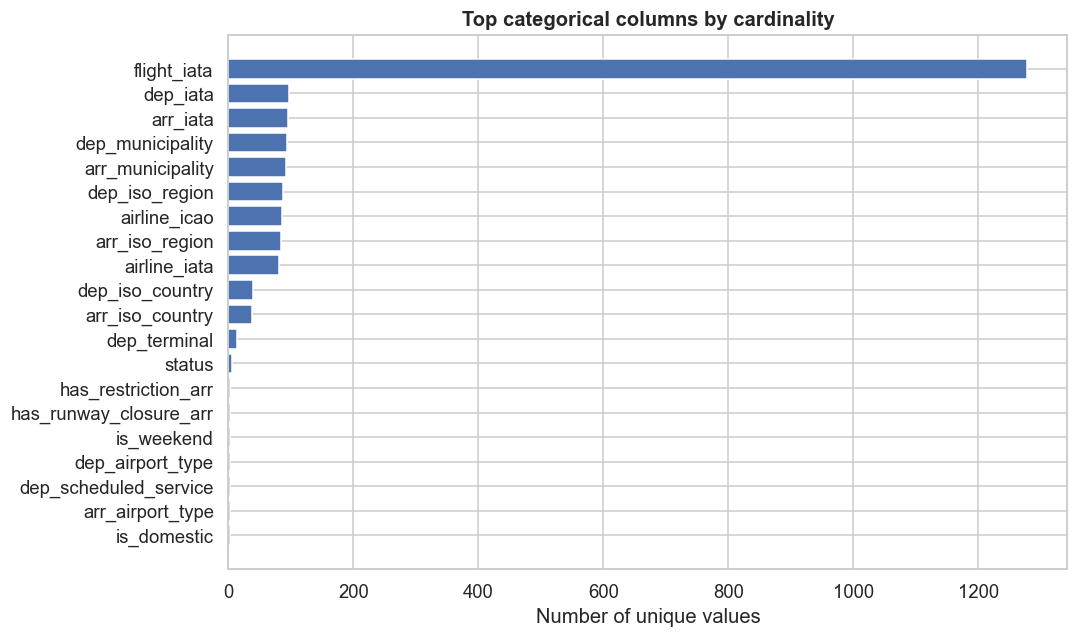

In [493]:
# ======================================================================
# ── 12. CATEGORICAL CARDINALITY ANALYSIS
# ======================================================================

print("\n" + "="*80)
print("12. CATEGORICAL CARDINALITY ANALYSIS")
print("="*80)

cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Убираем target из списка признаков
cat_cols = [c for c in cat_cols if c not in ["is_delayed"]]

cardinality_rows = []

for col in cat_cols:
    n_unique = df[col].nunique(dropna=True)
    missing_pct = df[col].isna().mean() * 100
    top_value = df[col].value_counts(dropna=True).index[0] if df[col].notna().any() else np.nan
    top_value_pct = df[col].value_counts(normalize=True, dropna=True).iloc[0] * 100 if df[col].notna().any() else np.nan
    
    cardinality_rows.append({
        "column": col,
        "n_unique": n_unique,
        "missing_pct": round(missing_pct, 2),
        "top_value": top_value,
        "top_value_pct": round(top_value_pct, 2)
    })

cardinality_df = (
    pd.DataFrame(cardinality_rows)
    .sort_values(["n_unique", "missing_pct"], ascending=[False, False])
)

display(cardinality_df)

cardinality_df.to_csv(DATA_DIR / "categorical_cardinality.csv", index=False)

# График top categorical cardinality
top_card = cardinality_df.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_card["column"], top_card["n_unique"], color="#4C72B0", edgecolor="white")
ax.set_xlabel("Number of unique values")
ax.set_title("Top categorical columns by cardinality")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_19_categorical_cardinality.png", bbox_inches="tight")
plt.show()

In [494]:
# ======================================================================
# ── 13. GROUP RELIABILITY ANALYSIS
# ======================================================================

print("\n" + "="*80)
print("13. GROUP RELIABILITY ANALYSIS")
print("="*80)

df_labeled = df.dropna(subset=["is_delayed", "dep_delay_min"]).copy()
df_labeled["is_delayed"] = df_labeled["is_delayed"].astype(bool)

def group_delay_summary(data, group_col, min_count=20):
    summary = (
        data.groupby(group_col)
        .agg(
            count=("is_delayed", "count"),
            delay_rate=("is_delayed", "mean"),
            avg_delay_min=("dep_delay_min", "mean"),
            median_delay_min=("dep_delay_min", "median"),
            max_delay_min=("dep_delay_min", "max")
        )
        .reset_index()
    )
    summary["delay_rate_pct"] = summary["delay_rate"] * 100
    summary = summary.sort_values(["delay_rate", "count"], ascending=[False, False])
    
    reliable = summary[summary["count"] >= min_count].copy()
    rare = summary[summary["count"] < min_count].copy()
    
    return summary, reliable, rare

group_configs = [
    ("dep_iata", 20),
    ("arr_iata", 20),
    ("airline_iata", 15),
    ("dep_iso_country", 20),
    ("arr_iso_country", 20),
]

for group_col, min_count in group_configs:
    if group_col not in df_labeled.columns:
        continue

    summary, reliable, rare = group_delay_summary(df_labeled, group_col, min_count=min_count)
    
    print(f"\n--- {group_col} ---")
    print(f"Total groups: {summary.shape[0]}")
    print(f"Reliable groups with count >= {min_count}: {reliable.shape[0]}")
    print(f"Rare groups with count < {min_count}: {rare.shape[0]}")
    
    print("\nTop reliable groups by delay rate:")
    display(
        reliable[[group_col, "count", "delay_rate_pct", "avg_delay_min", "median_delay_min", "max_delay_min"]]
        .head(15)
        .round(2)
    )
    
    summary.to_csv(DATA_DIR / f"group_summary_{group_col}.csv", index=False)

# Route-level reliability
if {"dep_iata", "arr_iata"}.issubset(df_labeled.columns):
    df_labeled["route"] = df_labeled["dep_iata"].astype(str) + " → " + df_labeled["arr_iata"].astype(str)

    route_summary, route_reliable, route_rare = group_delay_summary(df_labeled, "route", min_count=10)

    print("\n--- route ---")
    print(f"Total routes: {route_summary.shape[0]}")
    print(f"Reliable routes with count >= 10: {route_reliable.shape[0]}")
    print(f"Rare routes with count < 10: {route_rare.shape[0]}")

    display(
        route_reliable[["route", "count", "delay_rate_pct", "avg_delay_min", "median_delay_min", "max_delay_min"]]
        .head(20)
        .round(2)
    )

    route_summary.to_csv(DATA_DIR / "group_summary_route.csv", index=False)


13. GROUP RELIABILITY ANALYSIS

--- dep_iata ---
Total groups: 89
Reliable groups with count >= 20: 42
Rare groups with count < 20: 47

Top reliable groups by delay rate:


,dep_iata,count,delay_rate_pct,avg_delay_min,median_delay_min,max_delay_min
20,DXB,48,100.00,39.17,34.0,161.0
16,DEL,123,92.68,40.73,36.0,166.0
30,HGH,21,85.71,27.81,23.0,99.0
34,ICN,132,83.33,34.02,27.0,149.0
10,CAN,22,81.82,43.55,35.0,131.0
71,SVX,30,76.67,49.17,21.0,270.0
86,XIY,21,76.19,44.43,44.0,118.0
27,FRA,94,75.53,43.37,23.0,915.0
64,PVG,28,75.00,33.32,18.5,303.0
83,VKO,75,73.33,54.97,23.0,630.0



--- arr_iata ---
Total groups: 87
Reliable groups with count >= 20: 41
Rare groups with count < 20: 46

Top reliable groups by delay rate:


,arr_iata,count,delay_rate_pct,avg_delay_min,median_delay_min,max_delay_min
27,HGH,20,80.00,27.70,28.5,75.0
18,DXB,44,68.18,24.18,20.5,60.0
11,CAN,22,68.18,28.82,26.5,75.0
43,LGG,33,66.67,42.09,21.0,325.0
29,HKT,21,61.90,22.14,19.0,60.0
32,IST,359,61.84,26.43,20.0,945.0
63,SAW,52,61.54,28.81,18.0,335.0
55,PEK,40,60.00,21.35,20.0,51.0
31,ICN,94,59.57,20.15,19.0,57.0
61,PVG,27,59.26,20.56,18.0,49.0



--- airline_iata ---
Total groups: 74
Reliable groups with count >= 15: 46
Rare groups with count < 15: 28

Top reliable groups by delay rate:


...

,dep_iso_country,count,delay_rate_pct,avg_delay_min,median_delay_min,max_delay_min
0,AE,48,100.00,39.17,34.0,161.0
16,IN,147,87.07,37.62,33.0,166.0
20,KR,132,83.33,34.02,27.0,149.0
8,DE,95,75.79,44.65,23.0,915.0
36,VN,25,72.00,52.12,21.0,445.0
34,TR,490,62.65,30.04,19.0,490.0
3,BE,23,60.87,28.65,18.0,102.0
5,CN,305,60.33,29.38,20.0,434.0
32,TH,81,54.32,17.12,18.0,69.0
31,RU,320,54.06,31.04,17.0,630.0



--- arr_iso_country ---
Total groups: 35
Reliable groups with count >= 20: 17
Rare groups with count < 20: 18

Top reliable groups by delay rate:


,arr_iso_country,count,delay_rate_pct,avg_delay_min,median_delay_min,max_delay_min
10,GB,28,71.43,21.00,19.0,56.0
0,AE,45,68.89,25.20,21.0,70.0
32,TR,455,60.88,26.23,20.0,945.0
19,KR,94,59.57,20.15,19.0,57.0
3,BE,49,57.14,34.18,17.0,325.0
7,DE,116,55.17,24.45,19.0,90.0
30,TH,70,52.86,18.93,17.5,60.0
14,HU,30,50.00,25.40,14.0,190.0
34,VN,22,50.00,17.23,15.5,50.0
16,IN,121,48.76,16.45,15.0,47.0



--- route ---
Total routes: 333
Reliable routes with count >= 10: 172
Rare routes with count < 10: 161


,route,count,delay_rate_pct,avg_delay_min,median_delay_min,max_delay_min
131,DXB → ALA,46,100.00,39.91,35.0,161.0
166,ICN → ALA,101,96.04,39.52,29.0,149.0
125,DEL → ALA,123,92.68,40.73,36.0,166.0
196,LHR → ALA,10,90.00,33.00,31.0,61.0
76,ALA → VIE,17,88.24,31.76,35.0,52.0
301,SZX → CIT,17,88.24,40.59,40.0,92.0
192,LED → NQZ,15,86.67,27.93,27.0,60.0
160,HGH → ALA,21,85.71,27.81,23.0,99.0
39,ALA → KUL,12,83.33,26.00,23.5,49.0
144,FRA → ALA,40,82.50,71.68,29.0,915.0


In [495]:
# ======================================================================
# ── 14. TEMPORAL SPLIT DIAGNOSTICS WITHOUT TRAINING
# ======================================================================

print("\n" + "="*80)
print("14. TEMPORAL SPLIT DIAGNOSTICS WITHOUT TRAINING")
print("="*80)

df_time = df_labeled.sort_values("dep_scheduled_utc").copy()

# 80/20 chronological split, без обучения модели
split_idx = int(len(df_time) * 0.8)

eda_train = df_time.iloc[:split_idx].copy()
eda_test = df_time.iloc[split_idx:].copy()

split_date = eda_test["dep_scheduled_utc"].min()

print(f"\nChronological split point: {split_date}")
print(f"EDA train period: {eda_train['dep_scheduled_utc'].min()} → {eda_train['dep_scheduled_utc'].max()}")
print(f"EDA test period:  {eda_test['dep_scheduled_utc'].min()} → {eda_test['dep_scheduled_utc'].max()}")
print(f"EDA train size: {len(eda_train):,}")
print(f"EDA test size:  {len(eda_test):,}")

print("\nTarget rate by split:")
print(pd.DataFrame({
    "split": ["eda_train", "eda_test"],
    "rows": [len(eda_train), len(eda_test)],
    "delay_rate": [eda_train["is_delayed"].mean(), eda_test["is_delayed"].mean()],
    "avg_delay_min": [eda_train["dep_delay_min"].mean(), eda_test["dep_delay_min"].mean()],
    "median_delay_min": [eda_train["dep_delay_min"].median(), eda_test["dep_delay_min"].median()],
}).round(3))

# 14.1 Numeric feature drift between train/test
numeric_cols_for_drift = [
    "route_distance_km",
    "hour_of_day",
    "day_of_week",
    "notam_count_dep",
    "notam_count_arr",
    "notam_count_route",
    "notam_active_dep",
    "notam_active_arr",
    "notam_max_hours_dep",
    "notam_max_hours_arr",
    "flights_dep_same_hour",
    "flights_arr_same_hour",
]

numeric_cols_for_drift = [c for c in numeric_cols_for_drift if c in df_time.columns]

drift_rows = []

for col in numeric_cols_for_drift:
    train_values = eda_train[col].dropna()
    test_values = eda_test[col].dropna()
    
    if len(train_values) == 0 or len(test_values) == 0:
        continue
    
    # KS-test only as EDA signal, not strict proof
    ks_stat, ks_p = stats.ks_2samp(train_values, test_values)
    
    drift_rows.append({
        "feature": col,
        "train_mean": train_values.mean(),
        "test_mean": test_values.mean(),
        "mean_diff": test_values.mean() - train_values.mean(),
        "train_median": train_values.median(),
        "test_median": test_values.median(),
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
    })

drift_df = pd.DataFrame(drift_rows).sort_values("ks_stat", ascending=False)

print("\nNumeric train/test drift diagnostics:")
display(drift_df.round(4))

drift_df.to_csv(DATA_DIR / "temporal_numeric_drift.csv", index=False)


14. TEMPORAL SPLIT DIAGNOSTICS WITHOUT TRAINING

Chronological split point: 2026-04-27 09:55:00+00:00
EDA train period: 2026-04-10 00:05:00+00:00 → 2026-04-27 09:55:00+00:00
EDA test period:  2026-04-27 09:55:00+00:00 → 2026-05-08 05:50:00+00:00
EDA train size: 7,006
EDA test size:  1,752

Target rate by split:
       split  rows  delay_rate  avg_delay_min  median_delay_min
0  eda_train  7006       0.461         19.795              14.0
1   eda_test  1752       0.404         20.604              13.0

Numeric train/test drift diagnostics:


,feature,train_mean,test_mean,mean_diff,train_median,test_median,ks_stat,ks_pvalue
2,day_of_week,3.2953,1.7414,-1.5539,4.00,2.00,0.4780,0.0000
4,notam_count_arr,8.5992,12.8992,4.3000,5.00,12.00,0.4136,0.0000
7,notam_active_arr,8.5992,12.8992,4.3000,5.00,12.00,0.4136,0.0000
5,notam_count_route,11.5340,16.6553,5.1213,11.00,14.00,0.3360,0.0000
3,notam_count_dep,6.0524,8.1073,2.0549,2.00,6.00,0.2158,0.0000
6,notam_active_dep,6.0524,8.1073,2.0549,2.00,6.00,0.2158,0.0000
9,notam_max_hours_arr,1468.6120,1569.7887,101.1767,2192.00,2192.00,0.1317,0.0000
8,notam_max_hours_dep,1504.5458,1608.3987,103.8529,2192.00,2192.00,0.1272,0.0000
11,flights_arr_same_hour,3.8587,3.8168,-0.0419,3.00,2.00,0.0527,0.0008
1,hour_of_day,12.4837,12.8248,0.3410,12.00,13.00,0.0359,0.0525


In [496]:
# 14.2 Categorical distribution shift
cat_cols_for_shift = [
    "dep_iata",
    "arr_iata",
    "airline_iata",
    "dep_iso_country",
    "arr_iso_country",
    "is_domestic",
    "is_international",
]

cat_cols_for_shift = [c for c in cat_cols_for_shift if c in df_time.columns]

shift_rows = []

for col in cat_cols_for_shift:
    train_dist = eda_train[col].value_counts(normalize=True, dropna=False)
    test_dist = eda_test[col].value_counts(normalize=True, dropna=False)
    
    all_categories = train_dist.index.union(test_dist.index)
    train_dist = train_dist.reindex(all_categories, fill_value=0)
    test_dist = test_dist.reindex(all_categories, fill_value=0)
    
    # Total variation distance
    tvd = 0.5 * np.abs(train_dist - test_dist).sum()
    
    unseen_in_train = set(test_dist[test_dist > 0].index) - set(train_dist[train_dist > 0].index)
    
    shift_rows.append({
        "feature": col,
        "n_train_categories": (train_dist > 0).sum(),
        "n_test_categories": (test_dist > 0).sum(),
        "unseen_categories_in_test": len(unseen_in_train),
        "total_variation_distance": tvd,
    })

shift_df = pd.DataFrame(shift_rows).sort_values("total_variation_distance", ascending=False)

print("\nCategorical train/test shift diagnostics:")
display(shift_df.round(4))

shift_df.to_csv(DATA_DIR / "temporal_categorical_shift.csv", index=False)


Categorical train/test shift diagnostics:


,feature,n_train_categories,n_test_categories,unseen_categories_in_test,total_variation_distance
0,dep_iata,89,73,0,0.0814
3,dep_iso_country,37,31,0,0.0630
2,airline_iata,73,59,1,0.0530
1,arr_iata,86,78,1,0.0512
5,is_domestic,2,2,0,0.0417
6,is_international,2,2,0,0.0417
4,arr_iso_country,35,32,0,0.0270


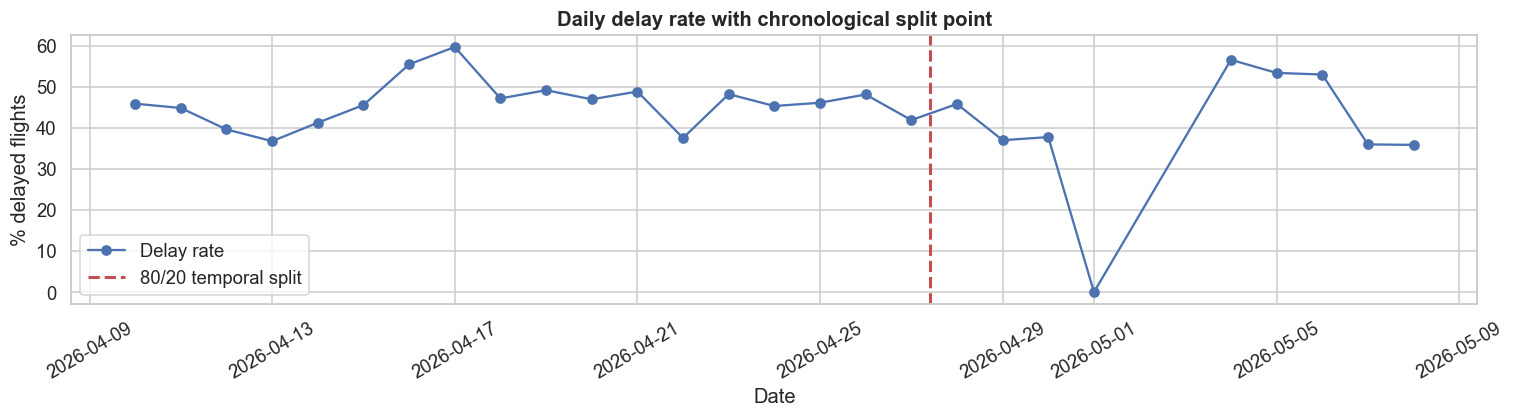

In [497]:
# 14.3 Plot target rate over time with split line
daily_split = (
    df_time.assign(date=df_time["dep_scheduled_utc"].dt.floor("D"))
    .groupby("date")
    .agg(
        delay_rate=("is_delayed", "mean"),
        count=("is_delayed", "count")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(
    daily_split["date"],
    daily_split["delay_rate"] * 100,
    marker="o",
    linewidth=1.5,
    color="#4C72B0",
    label="Delay rate"
)

ax1.axvline(split_date, color="#C44E52", linestyle="--", linewidth=2, label="80/20 temporal split")

ax1.set_xlabel("Date")
ax1.set_ylabel("% delayed flights")
ax1.set_title("Daily delay rate with chronological split point")
ax1.tick_params(axis="x", rotation=30)
ax1.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_20_temporal_split_target_rate.png", bbox_inches="tight")
plt.show()

In [498]:
# ======================================================================
# ── 15. FEATURE ENGINEERING FOR CLEANED MODELING DATASET
# ======================================================================

print("\n" + "="*80)
print("15. FEATURE ENGINEERING FOR CLEANED MODELING DATASET")
print("="*80)

df_model = df.copy()

# 15.1 Оставляем только строки с известным target
before = len(df_model)
df_model = df_model.dropna(subset=["dep_delay_min", "is_delayed"]).copy()
after = len(df_model)

print(f"\nDrop rows without target: {before:,} → {after:,}")

# 15.2 Убираем особые operational outcomes, которые лучше не смешивать с baseline departure delay task
# Важно: НЕ оставляем только landed, потому что в active тоже могут быть строки с известным departure delay.
# Убираем только cancelled/diverted как отдельные редкие сценарии.
excluded_statuses = ["cancelled", "diverted"]

before = len(df_model)
df_model = df_model[~df_model["status"].isin(excluded_statuses)].copy()
after = len(df_model)

print(f"Remove statuses {excluded_statuses}: {before:,} → {after:,}")

# 15.3 Пересоздаем target, чтобы не зависеть от возможных ошибок в исходном is_delayed
df_model["is_delayed"] = (df_model["dep_delay_min"] > 15).astype(int)

# 15.4 Time features from scheduled departure timestamp
df_model["dep_scheduled_utc"] = pd.to_datetime(df_model["dep_scheduled_utc"], utc=True)

df_model["dep_hour"] = df_model["dep_scheduled_utc"].dt.hour
df_model["dep_dayofweek"] = df_model["dep_scheduled_utc"].dt.dayofweek
df_model["dep_day"] = df_model["dep_scheduled_utc"].dt.day
df_model["dep_month"] = df_model["dep_scheduled_utc"].dt.month
df_model["dep_is_weekend"] = df_model["dep_dayofweek"].isin([5, 6]).astype(int)

# Cyclical encoding for hour and day of week
df_model["dep_hour_sin"] = np.sin(2 * np.pi * df_model["dep_hour"] / 24)
df_model["dep_hour_cos"] = np.cos(2 * np.pi * df_model["dep_hour"] / 24)

df_model["dep_dow_sin"] = np.sin(2 * np.pi * df_model["dep_dayofweek"] / 7)
df_model["dep_dow_cos"] = np.cos(2 * np.pi * df_model["dep_dayofweek"] / 7)

# 15.5 Route feature
df_model["route"] = df_model["dep_iata"].astype(str) + "_" + df_model["arr_iata"].astype(str)


15. FEATURE ENGINEERING FOR CLEANED MODELING DATASET

Drop rows without target: 13,509 → 8,758
Remove statuses ['cancelled', 'diverted']: 8,758 → 8,743


In [499]:
# 15.6 Boolean conversion
bool_like_cols = [
    "is_weekend",
    "is_domestic",
    "is_international",
    "dep_scheduled_service",
    "arr_scheduled_service",
    "has_restriction_dep",
    "has_restriction_arr",
    "has_parachute_activity_dep",
    "has_military_exercise_dep",
    "has_runway_closure_dep",
    "has_runway_closure_arr",
    "has_airspace_restriction",
    "dep_notams_available",
    "arr_notams_available",
]

for col in bool_like_cols:
    if col in df_model.columns:
        if df_model[col].dtype == "object":
            df_model[col] = df_model[col].map({"t": 1, "f": 0, True: 1, False: 0})
        else:
            df_model[col] = df_model[col].astype("Int64")

In [500]:
# 15.7 NOTAM missing handling
# Логика: если NOTAM unavailable, то count/active/duration можно заполнить 0,
# но availability flag обязательно сохраняем как отдельный признак.
notam_count_cols = [
    "notam_count_dep",
    "notam_count_arr",
    "notam_count_route",
    "notam_active_dep",
    "notam_active_arr",
]

for col in notam_count_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0)

notam_duration_cols = [
    "notam_max_hours_dep",
    "notam_max_hours_arr",
]

for col in notam_duration_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0)

notam_bool_cols = [
    "has_restriction_dep",
    "has_restriction_arr",
    "has_parachute_activity_dep",
    "has_military_exercise_dep",
    "has_runway_closure_dep",
    "has_runway_closure_arr",
    "has_airspace_restriction",
]

for col in notam_bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0).astype(int)

In [501]:
# 15.8 Elevation missing handling
# Пропусков мало, поэтому можно импутировать медианой.
for col in ["dep_elevation_ft", "arr_elevation_ft"]:
    if col in df_model.columns:
        median_value = df_model[col].median()
        df_model[col] = df_model[col].fillna(median_value)

# 15.9 Terminal feature
# Для baseline убираем dep_terminal, но можно сохранить отдельный missing flag для анализа.
if "dep_terminal" in df_model.columns:
    df_model["dep_terminal_missing"] = df_model["dep_terminal"].isna().astype(int)

# 15.10 Rare category grouping
# Это не target encoding и не обучение. Просто укрупняем редкие категории, чтобы потом модель не переобучалась.
def group_rare_categories(data, col, min_count=20, new_value="OTHER"):
    counts = data[col].value_counts(dropna=False)
    rare_values = counts[counts < min_count].index
    return data[col].where(~data[col].isin(rare_values), new_value)

rare_grouping_config = {
    "dep_iata": 20,
    "arr_iata": 20,
    "airline_iata": 15,
    "route": 10,
    "dep_iso_country": 20,
    "arr_iso_country": 20,
}

for col, min_count in rare_grouping_config.items():
    if col in df_model.columns:
        new_col = f"{col}_grp"
        df_model[new_col] = group_rare_categories(df_model, col, min_count=min_count)
        print(f"{new_col}: {df_model[new_col].nunique()} categories after rare grouping")

dep_iata_grp: 43 categories after rare grouping
arr_iata_grp: 42 categories after rare grouping
airline_iata_grp: 47 categories after rare grouping
route_grp: 173 categories after rare grouping
dep_iso_country_grp: 17 categories after rare grouping
arr_iso_country_grp: 18 categories after rare grouping


In [502]:
# 15.11 Drop leakage / unstable / redundant columns
# dep_delay_min is intentionally kept in the cleaned CSV as the regression target
# and for error analysis. It must still be dropped from X in training notebooks.
drop_cols = [
    # leakage / post-event / metadata
    "status",
    "updated_at",
    
    # high-cardinality identifiers
    "flight_iata",
    "flight_number",
    
    # redundant airline representation
    "airline_icao",
    
    # too many missing values for baseline
    "dep_terminal",
    
    # old time columns if replaced by engineered features
    "hour_of_day",
    "day_of_week",
    "month",
    "season",
]

drop_cols_existing = [c for c in drop_cols if c in df_model.columns]

df_features = df_model.drop(columns=drop_cols_existing).copy()

In [503]:
# 15.12 Drop constant / near-constant columns after cleaning
target_col = "is_delayed"

feature_cols_tmp = [c for c in df_features.columns if c != target_col]

constant_cols = []
near_constant_cols = []

for col in feature_cols_tmp:
    nunique = df_features[col].nunique(dropna=False)
    
    if nunique <= 1:
        constant_cols.append(col)
    else:
        top_freq = df_features[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_freq >= 0.995:
            near_constant_cols.append(col)

print("\nConstant columns to drop:")
print(constant_cols)

print("\nNear-constant columns to drop:")
print(near_constant_cols)

df_features = df_features.drop(columns=constant_cols + near_constant_cols)

# Drop target duplicate and duplicated *_int helper columns before final checks/save.
# Example: keep is_domestic, drop is_domestic_int. Always drop is_delayed_int.
helper_int_cols_to_drop = [
    col
    for col in df_features.columns
    if col.endswith("_int") and (
        col == "is_delayed_int" or col[:-4] in df_features.columns
    )
]

print("\nHelper *_int columns to drop:")
print(helper_int_cols_to_drop)

df_features = df_features.drop(columns=helper_int_cols_to_drop)



Constant columns to drop:
['arr_scheduled_service', 'has_military_exercise_dep', 'arr_scheduled_service_int', 'has_military_exercise_dep_int']

Near-constant columns to drop:
['dep_airport_type', 'dep_scheduled_service', 'dep_scheduled_service_int']

Helper *_int columns to drop:
['is_delayed_int', 'is_weekend_int', 'is_domestic_int', 'is_international_int', 'has_restriction_dep_int', 'has_restriction_arr_int', 'has_parachute_activity_dep_int', 'has_runway_closure_dep_int', 'has_runway_closure_arr_int', 'has_airspace_restriction_int', 'dep_notams_available_int', 'arr_notams_available_int']


In [504]:
# 15.13 Final missing check
missing_final = df_features.isna().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

print("\nRemaining missing values after cleaning:")
display(missing_final)

# Если остались пропуски в categorical columns, заполним UNKNOWN
object_cols = df_features.select_dtypes(include=["object", "category"]).columns.tolist()
object_cols = [c for c in object_cols if c != target_col]

for col in object_cols:
    df_features[col] = df_features[col].fillna("UNKNOWN")

# Если остались пропуски в numeric columns, заполним медианой
numeric_cols = df_features.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target_col]

for col in numeric_cols:
    if df_features[col].isna().sum() > 0:
        df_features[col] = df_features[col].fillna(df_features[col].median())


Remaining missing values after cleaning:


Series([], dtype: int64)

In [505]:
# 15.14 Final checks
print("\nFinal cleaned dataset shape:", df_features.shape)
print("\nTarget distribution:")
print(df_features[target_col].value_counts())
print("\nTarget distribution, %:")
print((df_features[target_col].value_counts(normalize=True) * 100).round(2))

print("\nFinal dtypes:")
print(df_features.dtypes.value_counts())

print("\nRemaining NaN total:", df_features.isna().sum().sum())

display(df_features.head())


Final cleaned dataset shape: (8743, 57)

Target distribution:
is_delayed
0    4815
1    3928
Name: count, dtype: int64

Target distribution, %:
is_delayed
0    55.07
1    44.93
Name: proportion, dtype: float64

Final dtypes:
object                 17
float64                16
int32                  13
Int64                   5
int64                   5
datetime64[ns, UTC]     1
Name: count, dtype: int64

Remaining NaN total: 0


,dep_scheduled_utc,dep_iata,arr_iata,airline_iata,dep_delay_min,is_delayed,is_weekend,dep_latitude,dep_longitude,dep_elevation_ft,...,dep_dow_sin,dep_dow_cos,route,dep_terminal_missing,dep_iata_grp,arr_iata_grp,airline_iata_grp,route_grp,dep_iso_country_grp,arr_iso_country_grp
0,2026-04-10 00:05:00+00:00,SVO,ALA,SU,36.0,1,0,55.976858,37.411210,622.0,...,-0.433884,-0.900969,SVO_ALA,0,SVO,ALA,SU,SVO_ALA,RU,KZ
1,2026-04-10 00:40:00+00:00,IST,ALA,TK,19.0,1,0,41.274874,28.732136,325.0,...,-0.433884,-0.900969,IST_ALA,1,IST,ALA,TK,IST_ALA,TR,KZ
2,2026-04-10 00:40:00+00:00,IST,ALA,MS,19.0,1,0,41.274874,28.732136,325.0,...,-0.433884,-0.900969,IST_ALA,1,IST,ALA,MS,IST_ALA,TR,KZ
3,2026-04-10 00:40:00+00:00,IST,ALA,KC,19.0,1,0,41.274874,28.732136,325.0,...,-0.433884,-0.900969,IST_ALA,1,IST,ALA,KC,IST_ALA,TR,KZ
4,2026-04-10 00:50:00+00:00,LED,ALA,FV,16.0,1,0,59.800301,30.262501,78.0,...,-0.433884,-0.900969,LED_ALA,0,LED,ALA,FV,LED_ALA,RU,KZ


In [506]:
# 15.15 Save cleaned dataset

# Keep dep_scheduled_utc for chronological split in the training notebook.
# It will not be used as a model feature.
if "dep_scheduled_utc" in df_model.columns and "dep_scheduled_utc" not in df_features.columns:
    df_features["dep_scheduled_utc"] = df_model["dep_scheduled_utc"].values

# Make sure timestamp is saved as string in ISO-like format
if "dep_scheduled_utc" in df_features.columns:
    df_features["dep_scheduled_utc"] = pd.to_datetime(
        df_features["dep_scheduled_utc"],
        utc=True,
        errors="coerce"
    ).astype(str)


# Drop target duplicate and duplicated *_int helper columns before saving.
helper_int_cols_to_drop = [
    col
    for col in df_features.columns
    if col.endswith("_int") and (col == "is_delayed_int" or col[:-4] in df_features.columns)
]

df_features = df_features.drop(columns=helper_int_cols_to_drop)
print("Dropped helper *_int columns:", helper_int_cols_to_drop)

clean_path = DATA_DIR / "flight_features_cleaned_for_modeling.csv"
df_features.to_csv(clean_path, index=False)

print(f"\nCleaned modeling dataset saved to: {clean_path}")

Dropped helper *_int columns: []

Cleaned modeling dataset saved to: ..\data\flight_features_cleaned_for_modeling.csv


In [507]:
# ======================================================================
# ── 16. FINAL FEATURE LIST REPORT
# ======================================================================

print("\n" + "="*80)
print("16. FINAL FEATURE LIST REPORT")
print("="*80)

target_col = "is_delayed"

final_features = [c for c in df_features.columns if c != target_col]

feature_report = []

for col in final_features:
    feature_report.append({
        "feature": col,
        "dtype": str(df_features[col].dtype),
        "n_unique": df_features[col].nunique(dropna=False),
        "missing_count": df_features[col].isna().sum(),
        "missing_pct": round(df_features[col].isna().mean() * 100, 2),
    })

feature_report_df = (
    pd.DataFrame(feature_report)
    .sort_values(["dtype", "n_unique"], ascending=[True, False])
)

display(feature_report_df)

feature_report_df.to_csv(DATA_DIR / "final_feature_report.csv", index=False)

print("\nFinal feature report saved to:", DATA_DIR / "final_feature_report.csv")


16. FINAL FEATURE LIST REPORT


,feature,dtype,n_unique,missing_count,missing_pct
5,is_weekend,Int64,2,0,0.0
20,is_domestic,Int64,2,0,0.0
21,is_international,Int64,2,0,0.0
35,dep_notams_available,Int64,2,0,0.0
36,arr_notams_available,Int64,2,0,0.0
19,route_distance_km,float64,184,0,0.0
4,dep_delay_min,float64,164,0,0.0
6,dep_latitude,float64,89,0,0.0
7,dep_longitude,float64,89,0,0.0
13,arr_latitude,float64,87,0,0.0



Final feature report saved to: ..\data\final_feature_report.csv
